# Complete Data Modeling - No Data Leakage Pipeline

This notebook implements the correct machine learning pipeline for the liver cirrhosis dataset using only complete cases (107 samples with 10 features, no missing values).

The key principle is to split data first, then generate synthetic data from the training set only. This prevents data leakage where information from the test set could influence model training.

## Features

Numerical features: N_Days, Age, Bilirubin, Albumin, Platelets, Prothrombin

Categorical features: Sex, Edema, Stage

Target variable: Status

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import sqrtm
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from ctgan import CTGAN

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports successful")

Imports successful


## Explore Original Dataset

Load the full dataset and identify rows and columns without any missing values.

In [11]:
original_data = pd.read_csv('../data/raw/cirrhosis.csv')
original_data.head()


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [12]:
print("Original dataset shape:", original_data.shape)
print("\nMissing values per column:")
print(original_data.isnull().sum())
print("\nTotal missing values:", original_data.isnull().sum().sum())

Original dataset shape: (418, 20)

Missing values per column:
ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64

Total missing values: 1033


## Identify Complete Data

Find columns with no missing values and rows that are complete across all columns.

In [16]:
complete_cols = original_data.columns[original_data.isnull().sum() == 0].tolist()
print("Columns with no missing values:")
for col in complete_cols:
    print("-", col)

complete_rows = original_data.dropna()
print("\nRows with no missing values:", len(complete_rows))
print("Total rows:", len(original_data))

Columns with no missing values:
- ID
- N_Days
- Status
- Age
- Sex
- Edema
- Bilirubin
- Albumin

Rows with no missing values: 276
Total rows: 418


## Complete Columns and Rows

Extract only columns with no missing values and verify all rows are complete.

In [17]:
data_complete = original_data[complete_cols].copy()

print("Shape:", data_complete.shape)
print("\nMissing values:")
print(data_complete.isnull().sum())
print("\nAll rows complete:", data_complete.isnull().sum().sum() == 0)

Shape: (418, 8)

Missing values:
ID           0
N_Days       0
Status       0
Age          0
Sex          0
Edema        0
Bilirubin    0
Albumin      0
dtype: int64

All rows complete: True


In [19]:
data_complete.head()

,N_Days,Status,Age,Sex,Edema,Bilirubin,Albumin
0,400,D,21464,F,Y,14.5,2.60
1,4500,C,20617,F,N,1.1,4.14
2,1012,D,25594,M,S,1.4,3.48
3,1925,D,19994,F,S,1.8,2.54
4,1504,CL,13918,F,N,3.4,3.53


## Define Features

Separate numerical and categorical features. Remove ID as it is not a predictive feature.

In [18]:
data_complete = data_complete.drop(columns=['ID'])

num_cols = ['N_Days', 'Age', 'Bilirubin', 'Albumin']
cat_cols = ['Sex', 'Edema']
target = 'Status'

print("Numerical features:", num_cols)
print("Categorical features:", cat_cols)
print("Target:", target)
print("\nDataset shape:", data_complete.shape)
print("\nTarget distribution:")
print(data_complete[target].value_counts())

Numerical features: ['N_Days', 'Age', 'Bilirubin', 'Albumin']
Categorical features: ['Sex', 'Edema']
Target: Status

Dataset shape: (418, 7)

Target distribution:
Status
C     232
D     161
CL     25
Name: count, dtype: int64


## Exploratory Data Analysis

Explore the distribution of features and relationships in the complete dataset before splitting.

In [20]:
print("Dataset Summary")
print("="*50)
print("\nShape:", data_complete.shape)
print("\nData types:")
print(data_complete.dtypes)
print("\nDescriptive statistics:")
data_complete.describe()

Dataset Summary

Shape: (418, 7)

Data types:
N_Days         int64
Status        object
Age            int64
Sex           object
Edema         object
Bilirubin    float64
Albumin      float64
dtype: object

Descriptive statistics:


,N_Days,Age,Bilirubin,Albumin
count,418.000000,418.000000,418.000000,418.000000
mean,1917.782297,18533.351675,3.220813,3.497440
std,1104.672992,3815.845055,4.407506,0.424972
min,41.000000,9598.000000,0.300000,1.960000
25%,1092.750000,15644.500000,0.800000,3.242500
50%,1730.000000,18628.000000,1.400000,3.530000
75%,2613.500000,21272.500000,3.400000,3.770000
max,4795.000000,28650.000000,28.000000,4.640000


## Numerical Features Distribution

Visualize the distribution of numerical features to understand their spread and identify any outliers.

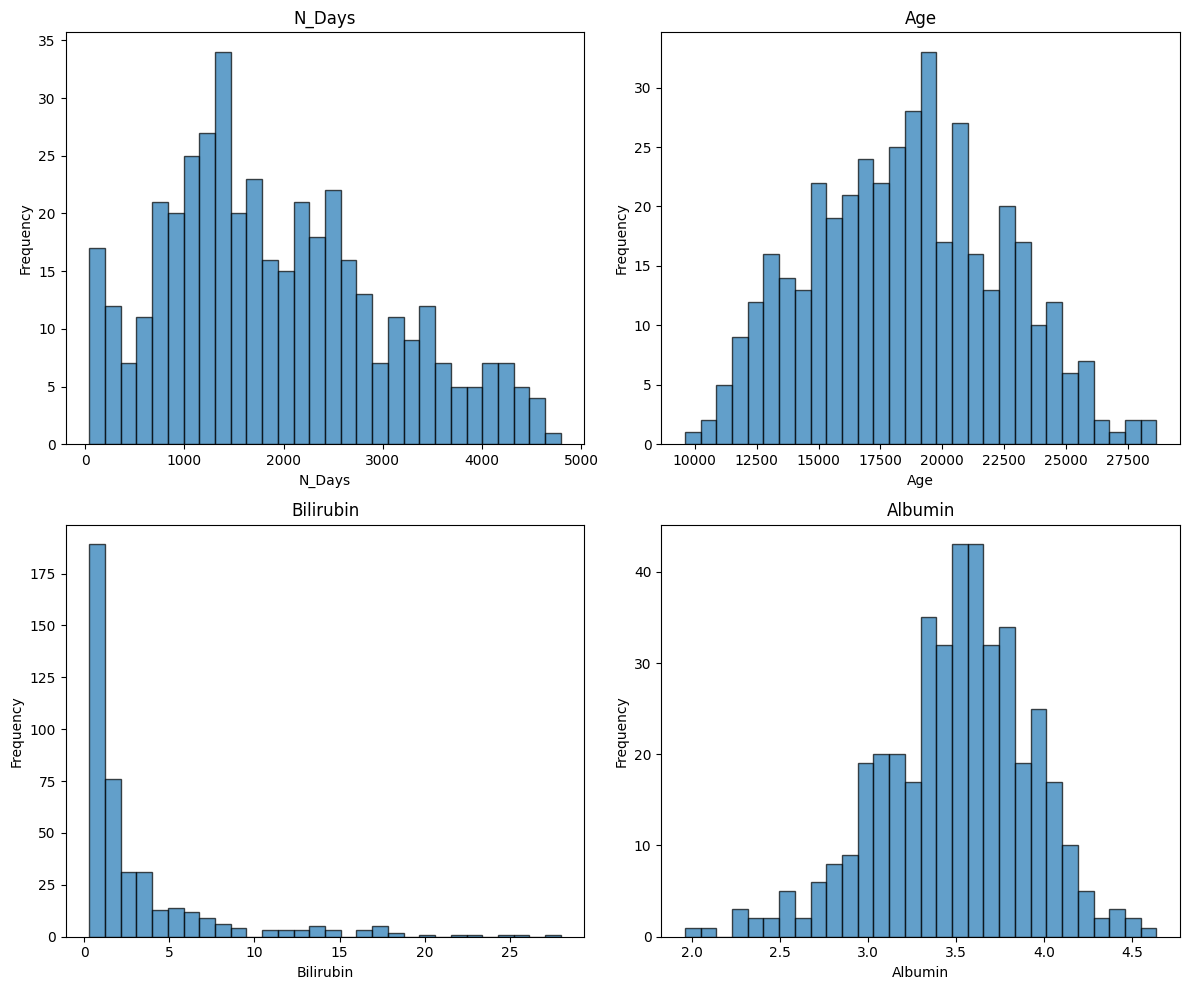

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(data_complete[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Convert Age to Years

The Age column is in days. Convert to years for better interpretability.

In [22]:
data_complete['Age'] = data_complete['Age'] / 365.25

print("Age statistics after conversion (in years):")
print(data_complete['Age'].describe())

Age statistics after conversion (in years):
count    418.000000
mean      50.741551
std       10.447214
min       26.277892
25%       42.832307
50%       51.000684
75%       58.240931
max       78.439425
Name: Age, dtype: float64


## Numerical Features Distribution

Visualize the distribution of numerical features after age conversion.

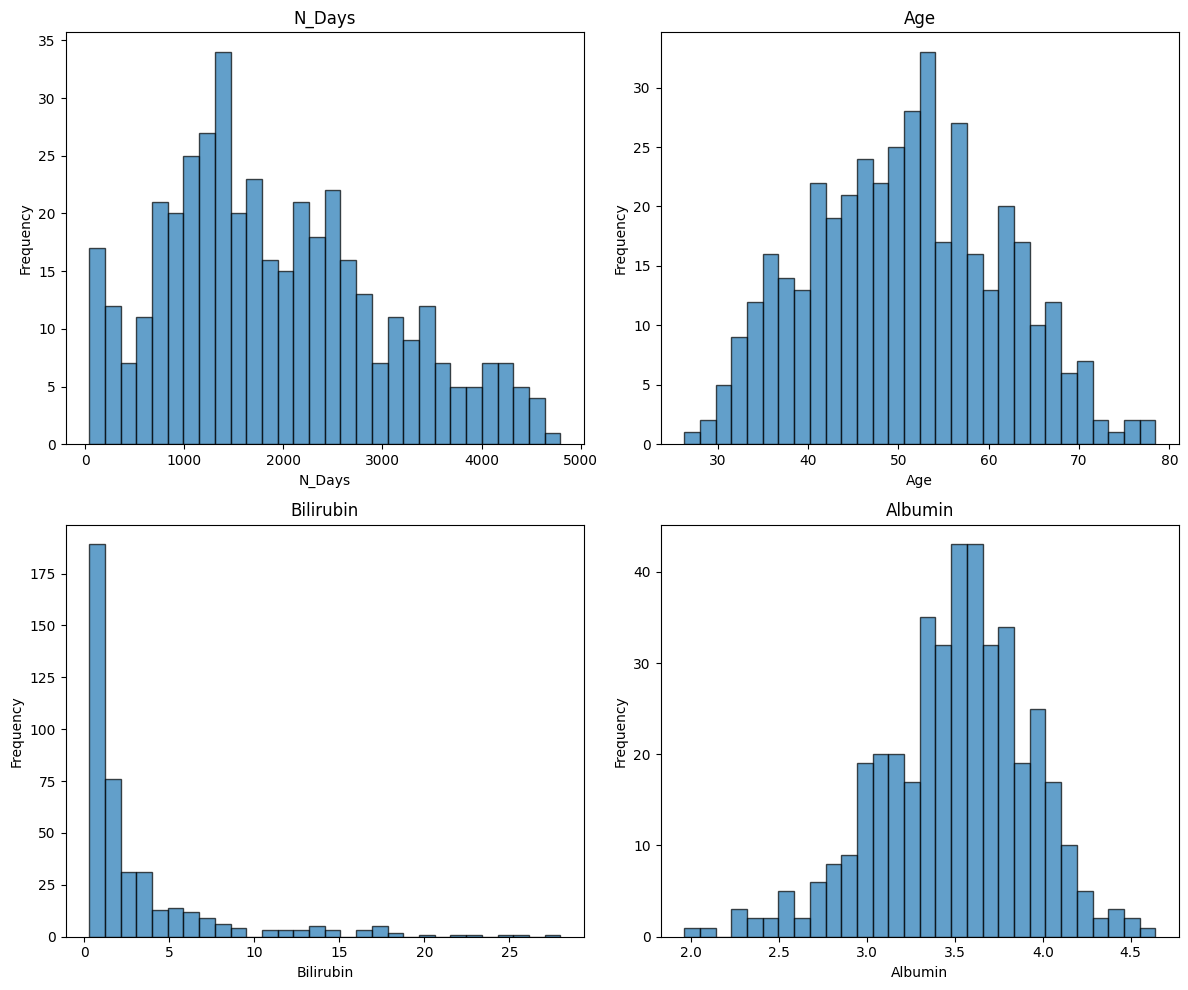

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(data_complete[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Categorical Features Distribution

Visualize the distribution of categorical features including the target variable.

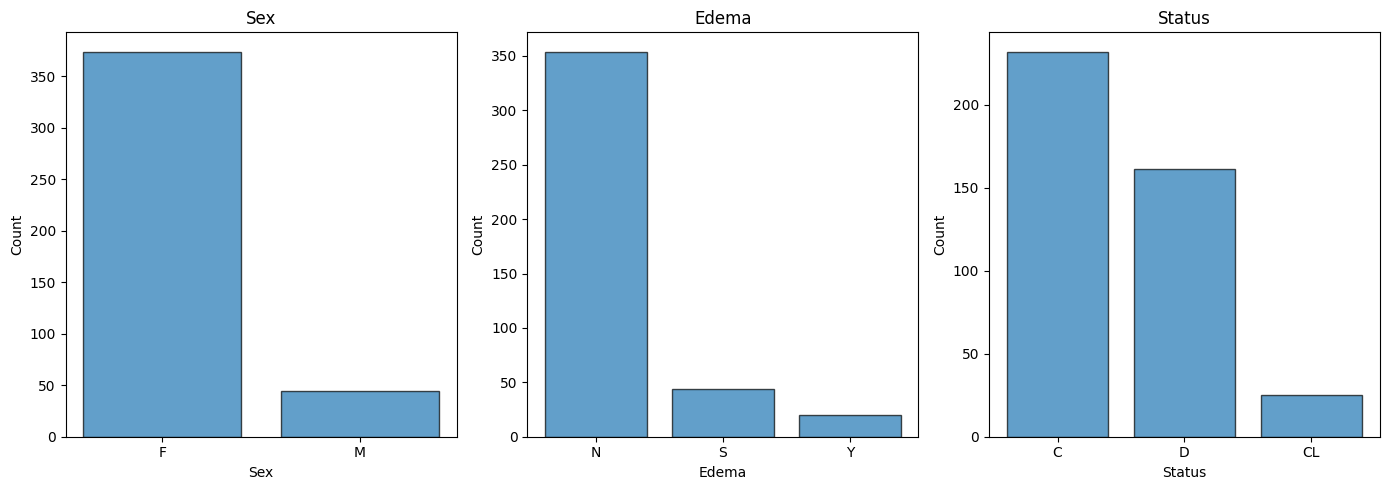

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(cat_cols + [target]):
    counts = data_complete[col].value_counts()
    axes[i].bar(counts.index, counts.values, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Feature Relationships with Target

Explore how numerical features differ across the three outcome categories.

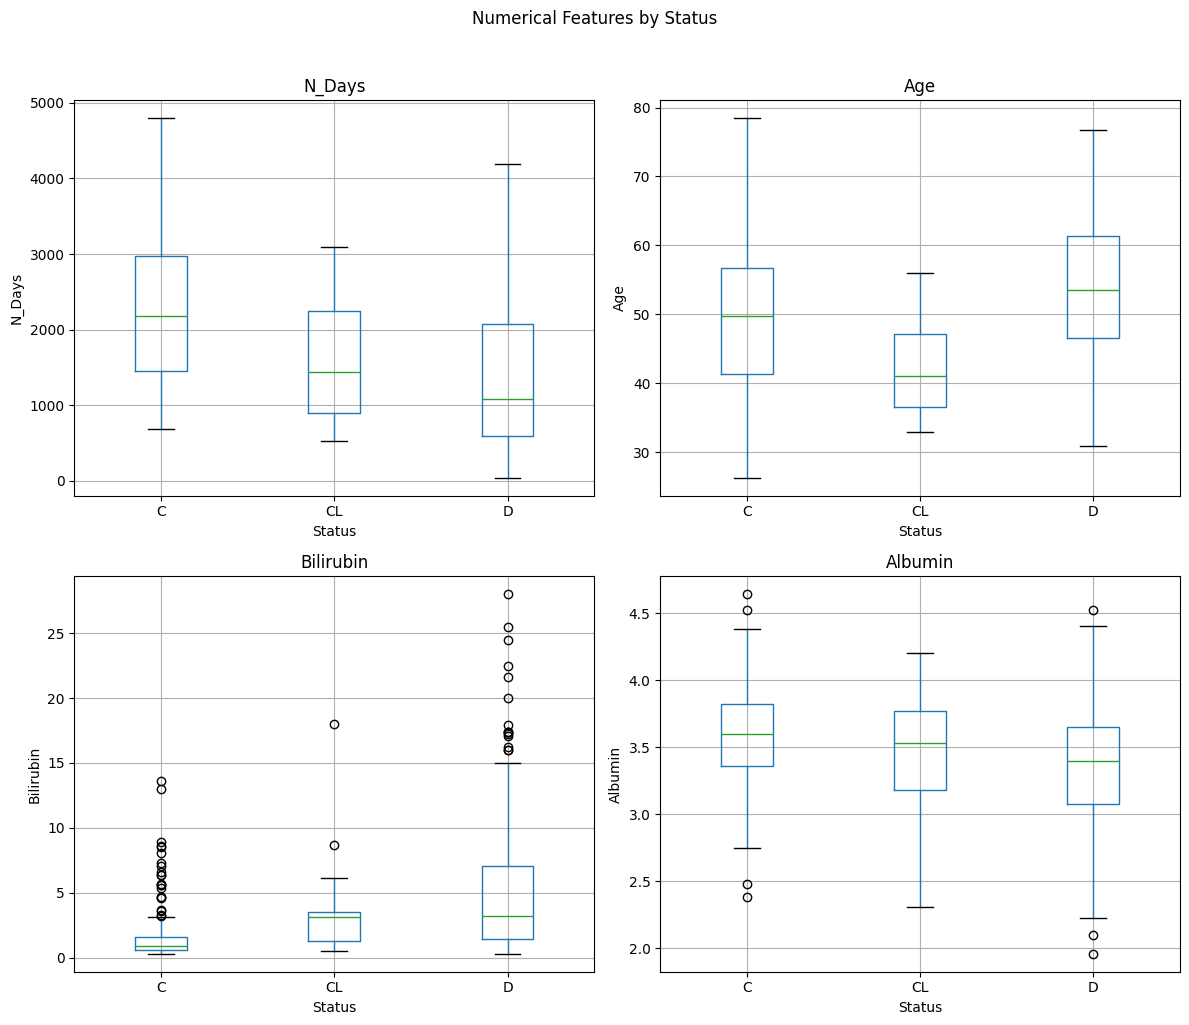

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_complete.boxplot(column=col, by=target, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Status')
    axes[i].set_ylabel(col)

plt.suptitle('Numerical Features by Status', y=1.02)
plt.tight_layout()
plt.show()

## Feature Relationships with Target (Improved)

Visualize how numerical features differ across outcome categories using violin plots with better styling.

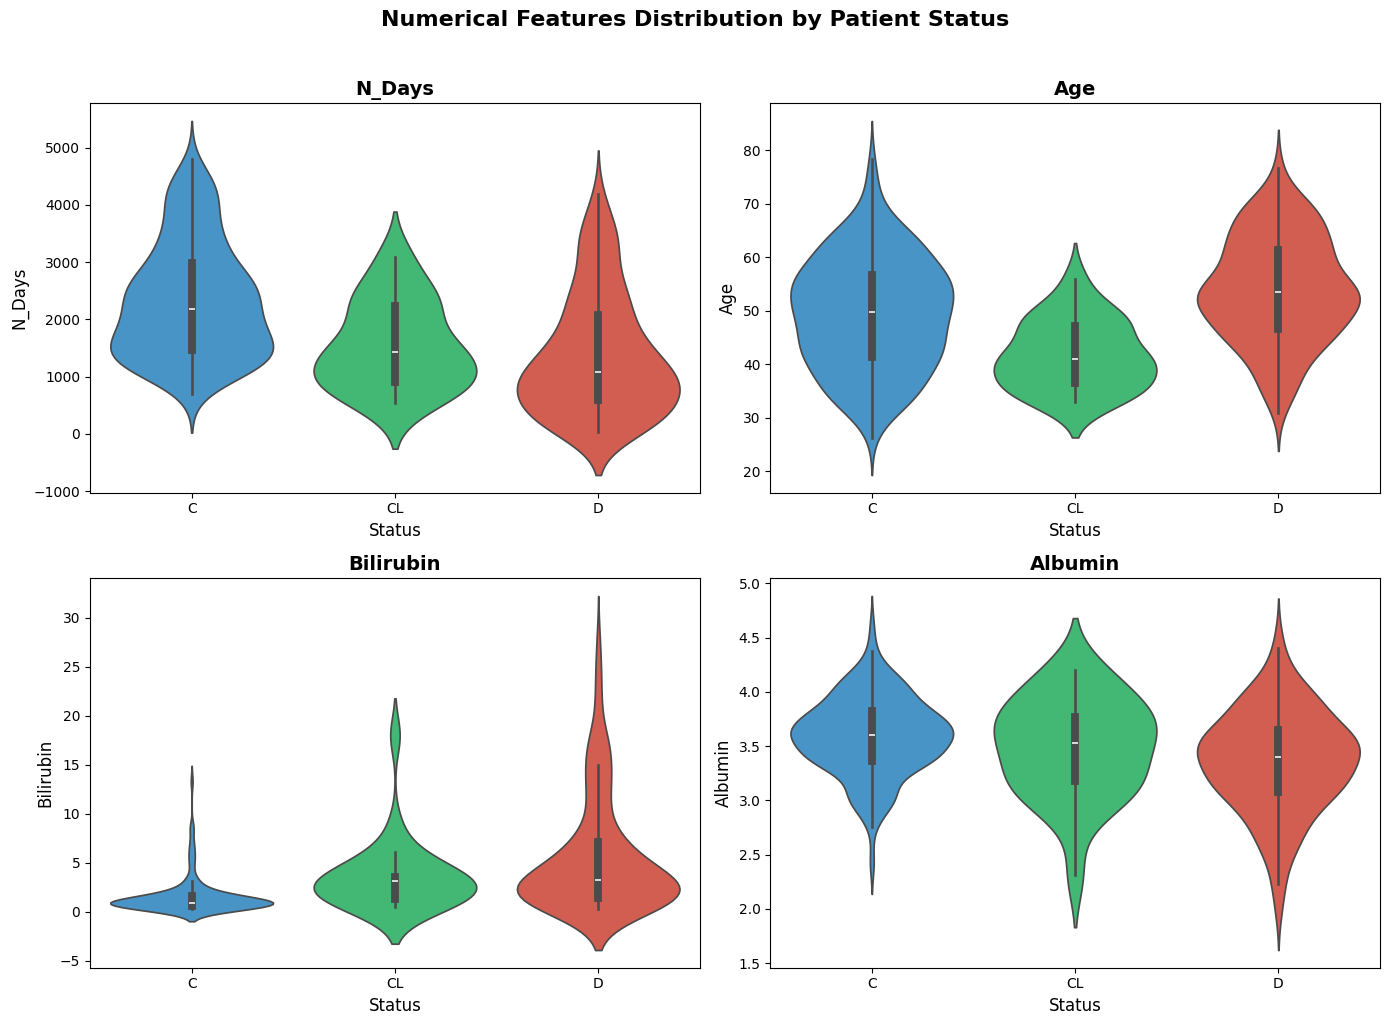

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = {'C': '#3498db', 'CL': '#2ecc71', 'D': '#e74c3c'}

for i, col in enumerate(num_cols):
    sns.violinplot(data=data_complete, x=target, y=col, ax=axes[i], 
                   palette=colors, order=['C', 'CL', 'D'])
    axes[i].set_title(col, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Status', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

plt.suptitle('Numerical Features Distribution by Patient Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Feature Relationships with Target

Visualize how numerical features differ across outcome categories using box plots with better styling.

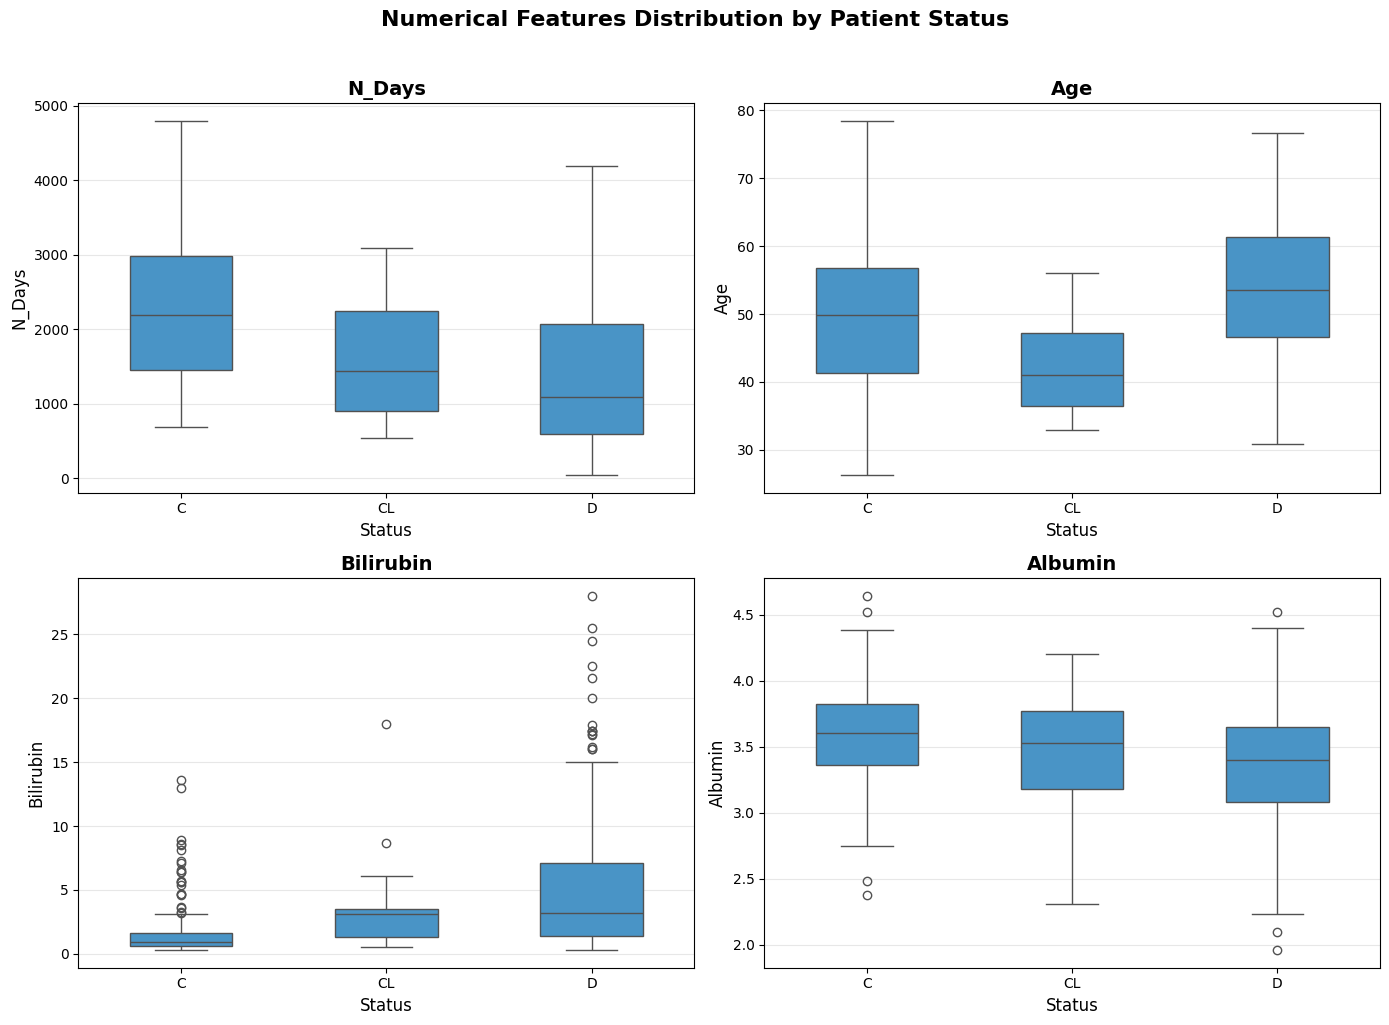

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=data_complete, x=target, y=col, ax=axes[i], 
                color='#3498db', order=['C', 'CL', 'D'], width=0.5)
    axes[i].set_title(col, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Status', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Numerical Features Distribution by Patient Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [31]:
print("Columns in data_complete:")
print(data_complete.columns.tolist())

Columns in data_complete:
['N_Days', 'Status', 'Age', 'Sex', 'Edema', 'Bilirubin', 'Albumin']


## Boxplots by Status and Edema

Compare numerical feature distributions across different patient status and edema conditions.

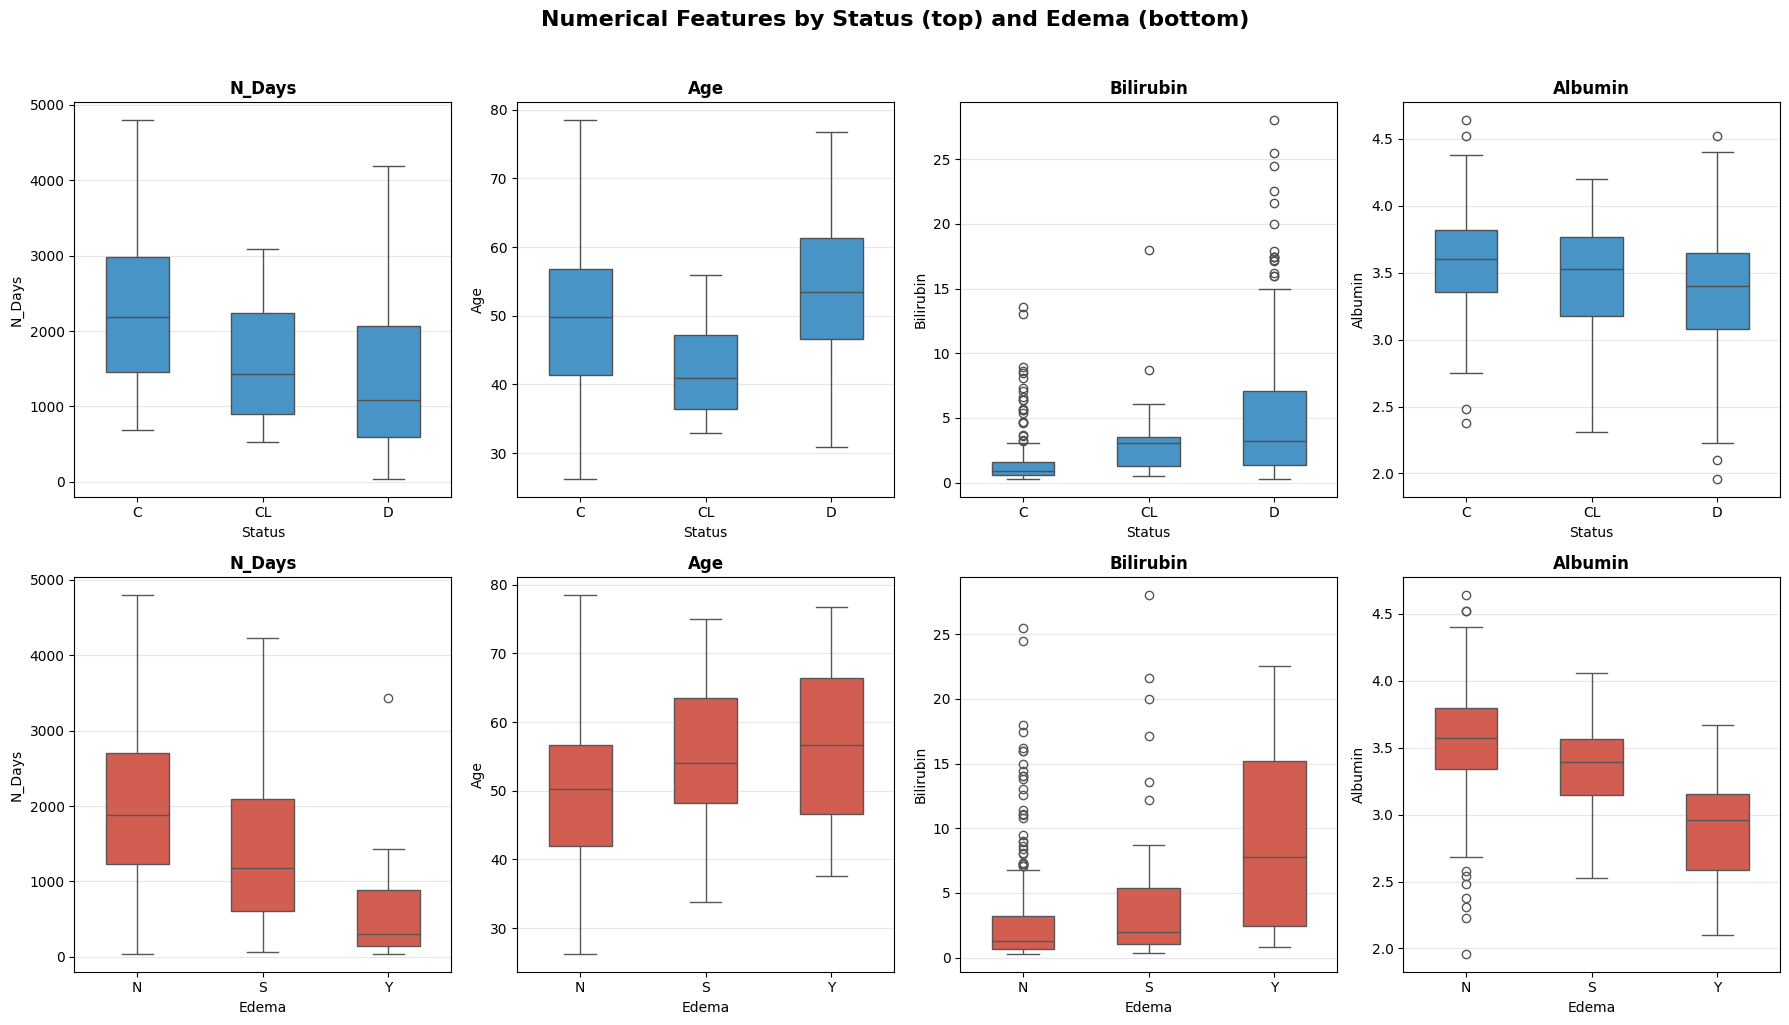

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for i, col in enumerate(num_cols):
    sns.boxplot(data=data_complete, x=target, y=col, ax=axes[0, i], 
                color='#3498db', order=['C', 'CL', 'D'], width=0.5)
    axes[0, i].set_title(col, fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('Status', fontsize=10)
    axes[0, i].set_ylabel(col, fontsize=10)
    axes[0, i].grid(axis='y', alpha=0.3)

for i, col in enumerate(num_cols):
    sns.boxplot(data=data_complete, x='Edema', y=col, ax=axes[1, i], 
                color='#e74c3c', order=['N', 'S', 'Y'], width=0.5)
    axes[1, i].set_title(col, fontsize=12, fontweight='bold')
    axes[1, i].set_xlabel('Edema', fontsize=10)
    axes[1, i].set_ylabel(col, fontsize=10)
    axes[1, i].grid(axis='y', alpha=0.3)

plt.suptitle('Numerical Features by Status (top) and Edema (bottom)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Numerical Features by Target Status

Visualize how each numerical feature differs across patient outcomes.

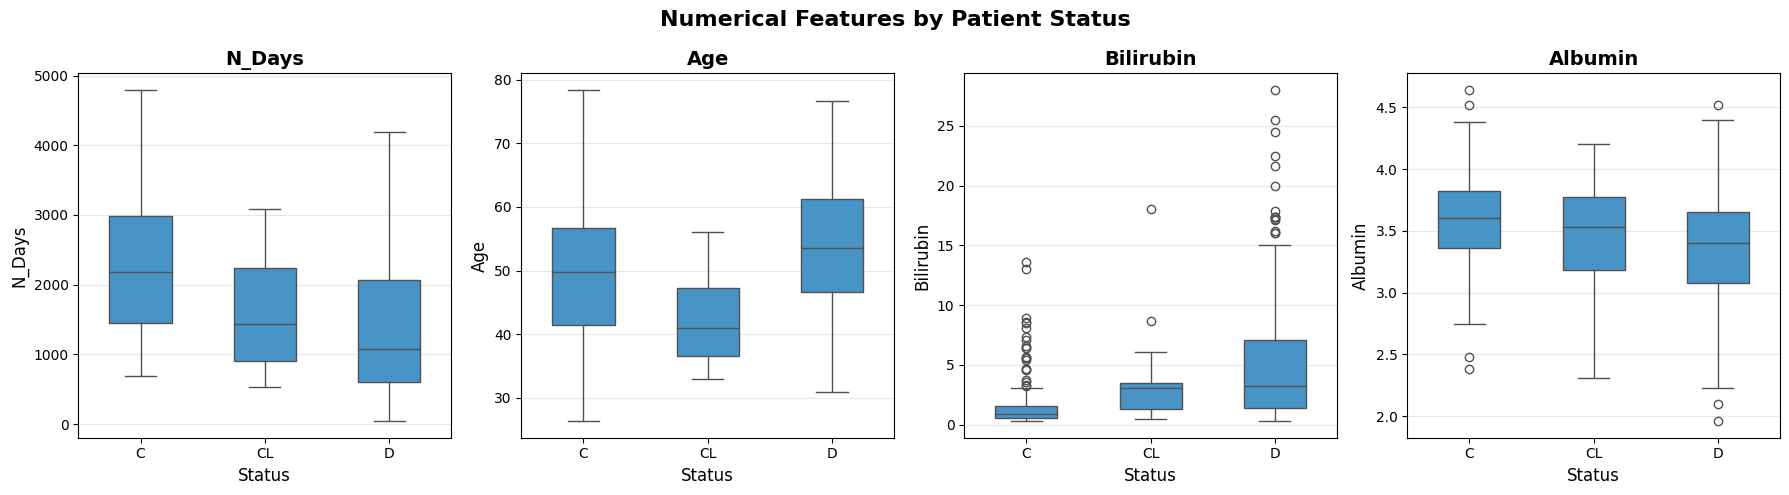

In [34]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=data_complete, x=target, y=col, ax=axes[i],
                color='#3498db', order=['C', 'CL', 'D'], width=0.5)
    axes[i].set_title(col, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Status', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Numerical Features by Patient Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/numerical_by_status.png', dpi=300, bbox_inches='tight')
plt.show()

## Numerical Features by Sex

Examine sex-based differences in clinical measurements.

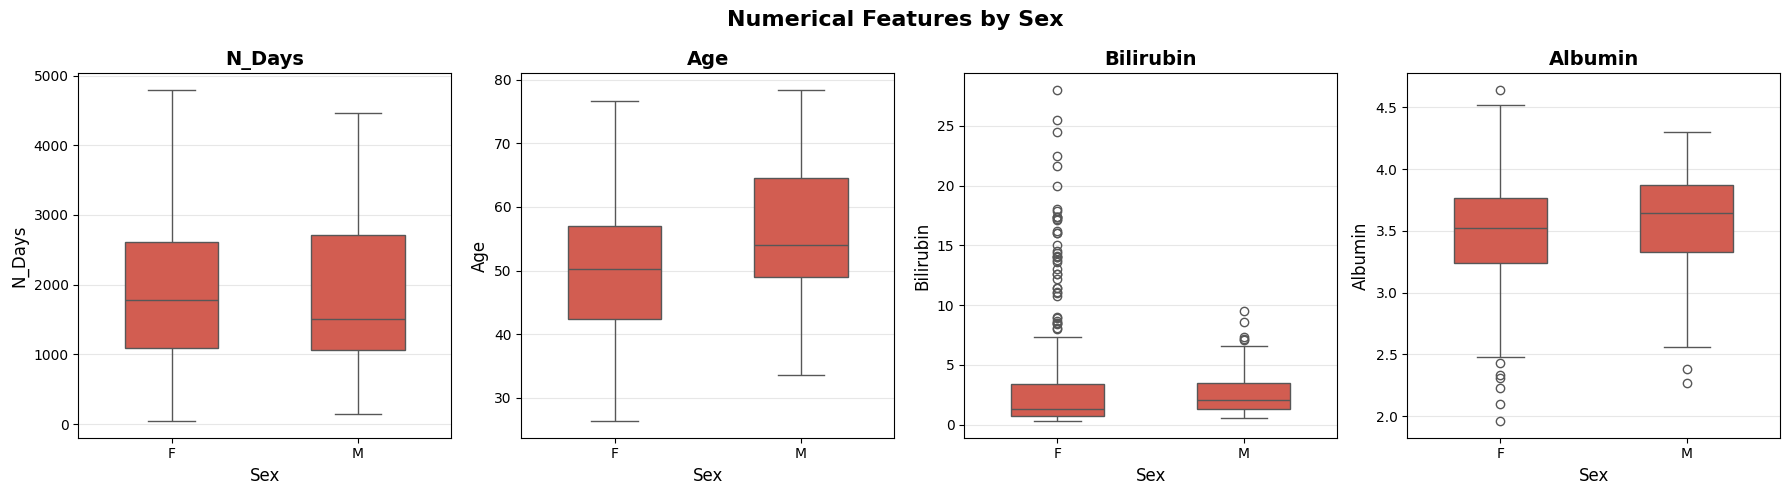

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=data_complete, x='Sex', y=col, ax=axes[i],
                color='#e74c3c', order=['F', 'M'], width=0.5)
    axes[i].set_title(col, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Sex', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Numerical Features by Sex', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/numerical_by_sex.png', dpi=300, bbox_inches='tight')
plt.show()

## Numerical Features by Edema

Examine how edema status relates to numerical features.

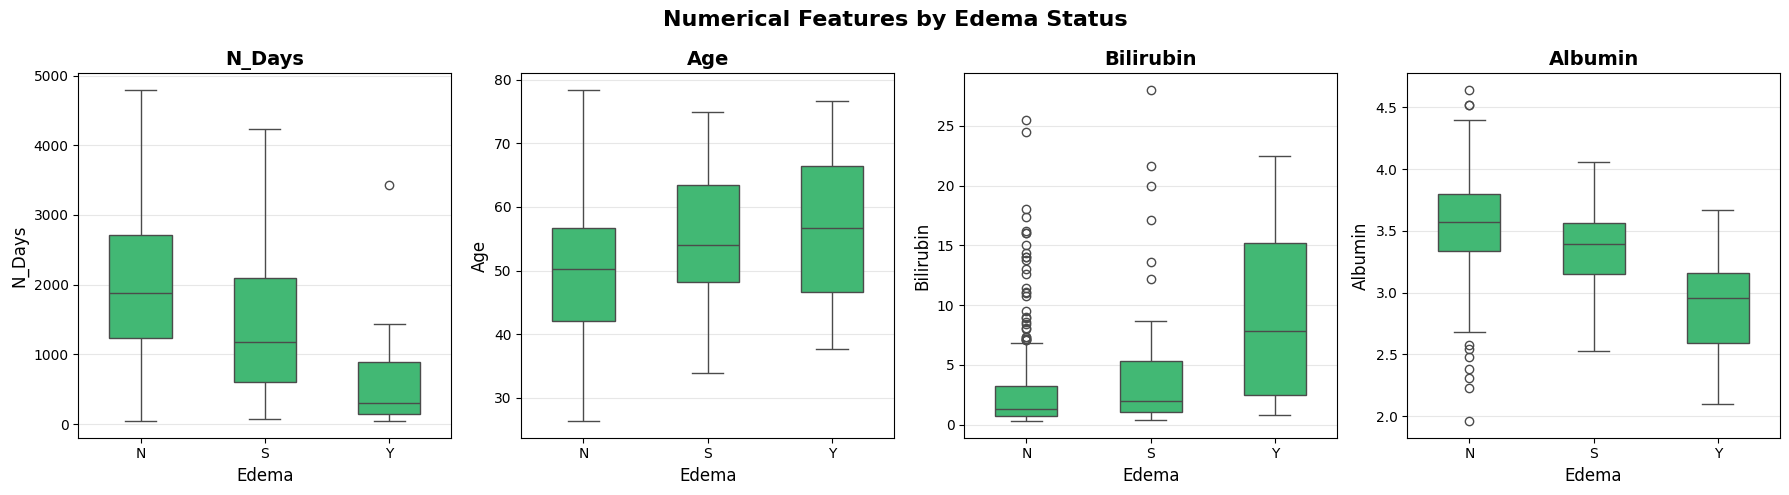

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=data_complete, x='Edema', y=col, ax=axes[i],
                color='#2ecc71', order=['N', 'S', 'Y'], width=0.5)
    axes[i].set_title(col, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Edema', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Numerical Features by Edema Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/numerical_by_edema.png', dpi=300, bbox_inches='tight')
plt.show()

## Combined View: Status by Sex

Grouped box plots showing numerical features by Status, split by Sex.

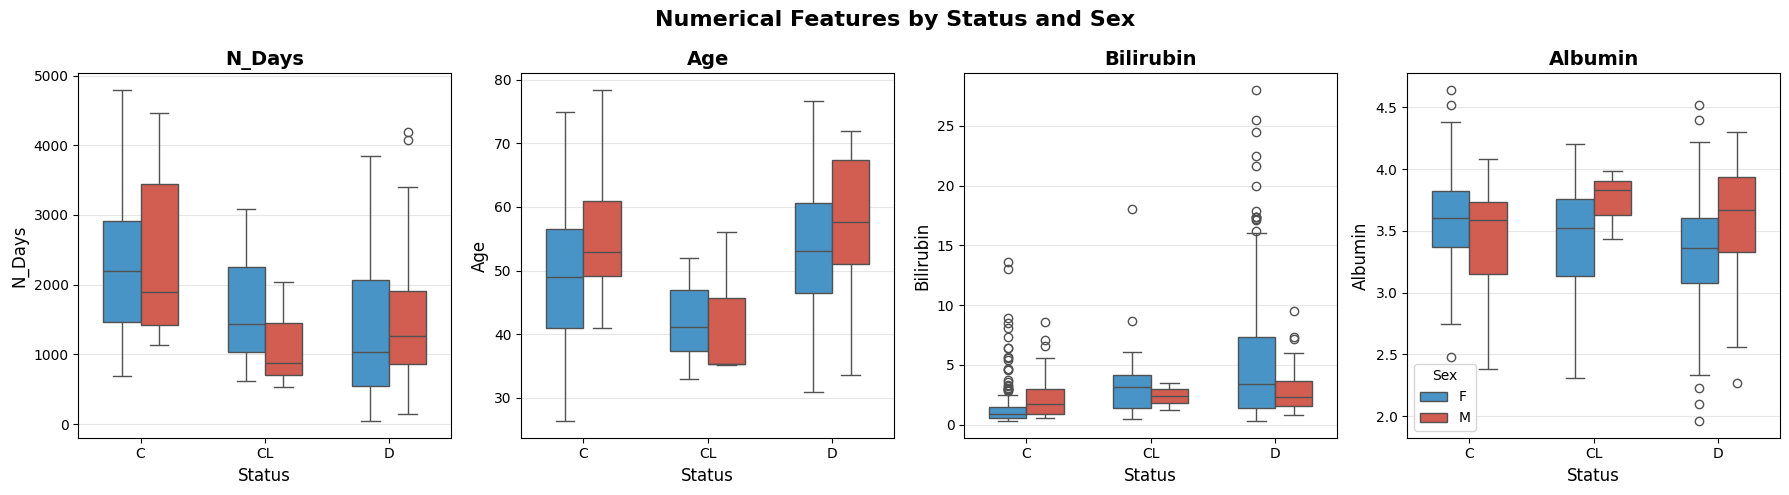

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=data_complete, x=target, y=col, hue='Sex', ax=axes[i],
                order=['C', 'CL', 'D'], width=0.6, palette=['#3498db', '#e74c3c'])
    axes[i].set_title(col, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Status', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].grid(axis='y', alpha=0.3)
    if i < 3:
        axes[i].get_legend().remove()

axes[3].legend(title='Sex', fontsize=10)

plt.suptitle('Numerical Features by Status and Sex', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/numerical_by_status_sex.png', dpi=300, bbox_inches='tight')
plt.show()

## Correlation Analysis

Examine the relationships between numerical features using a correlation heatmap.

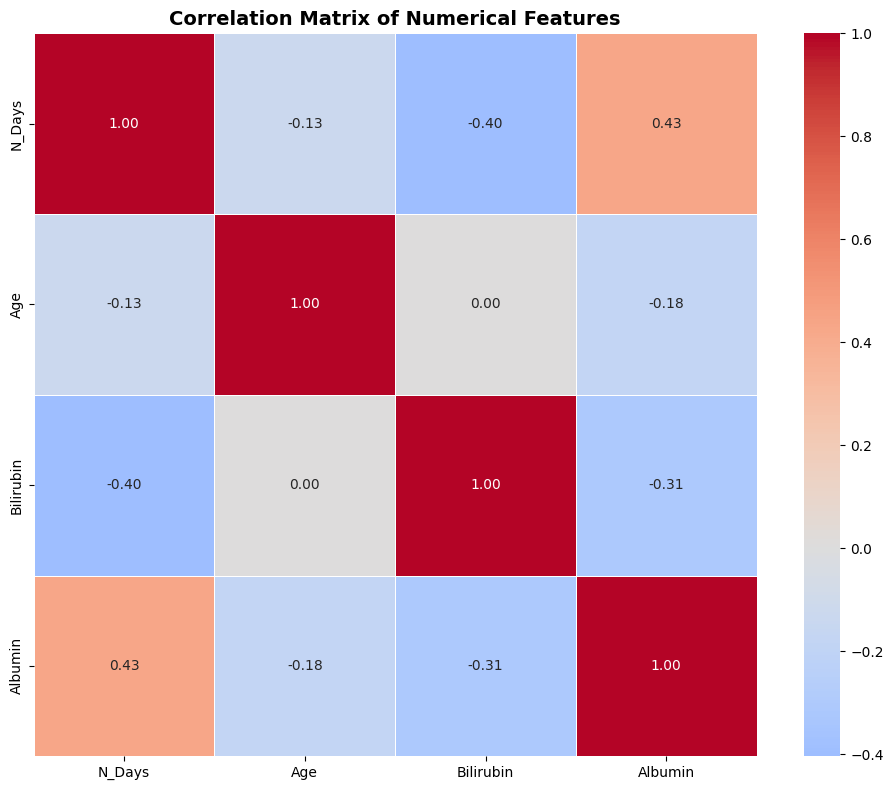

In [28]:
correlation = data_complete[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3D Visualization

Explore the relationship between three numerical features colored by patient status.

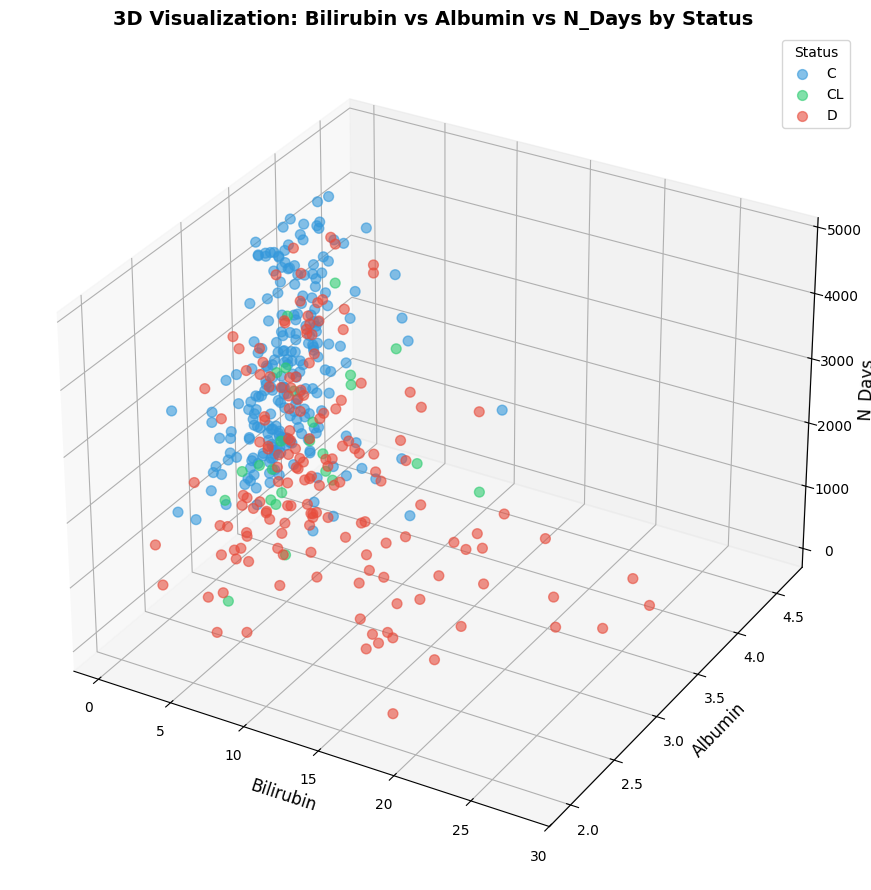

In [29]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors = {'C': '#3498db', 'CL': '#2ecc71', 'D': '#e74c3c'}

for status in ['C', 'CL', 'D']:
    subset = data_complete[data_complete[target] == status]
    ax.scatter(subset['Bilirubin'], subset['Albumin'], subset['N_Days'],
               c=colors[status], label=status, alpha=0.6, s=50)

ax.set_xlabel('Bilirubin', fontsize=12)
ax.set_ylabel('Albumin', fontsize=12)
ax.set_zlabel('N_Days', fontsize=12)
ax.set_title('3D Visualization: Bilirubin vs Albumin vs N_Days by Status', fontsize=14, fontweight='bold')
ax.legend(title='Status', fontsize=10)

plt.tight_layout()
plt.show()

## 3D Visualizations

Explore relationships between numerical features in three dimensions, colored by patient status.

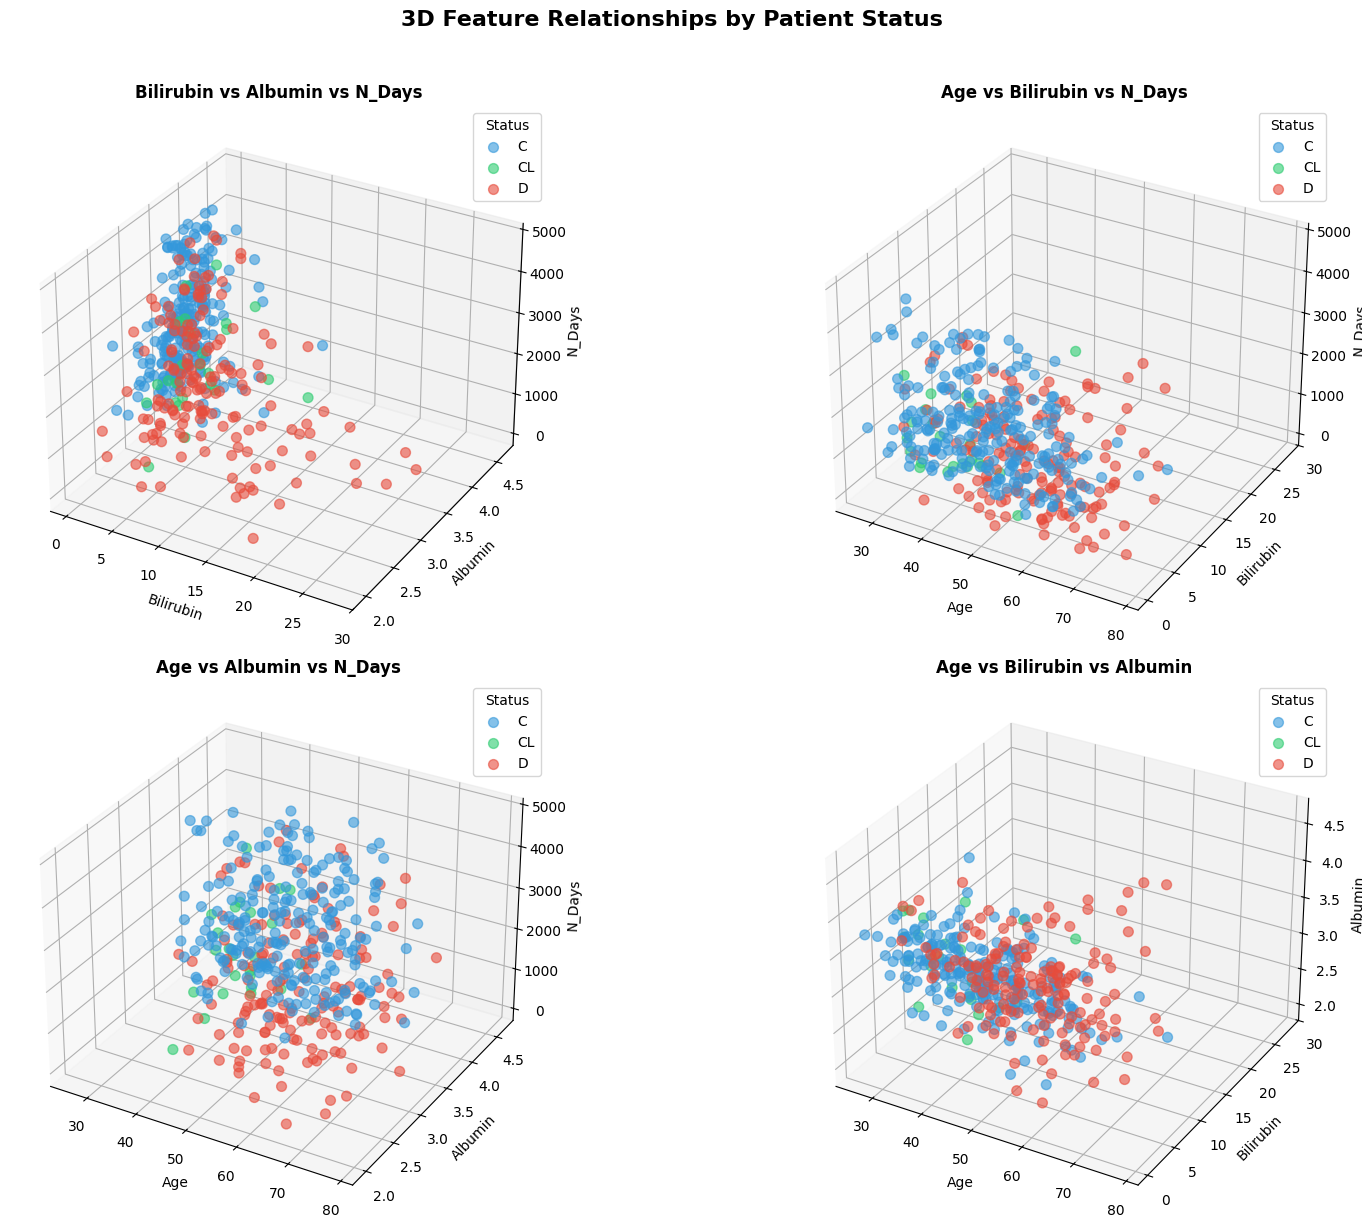

In [33]:

fig = plt.figure(figsize=(18, 12))

colors = {'C': '#3498db', 'CL': '#2ecc71', 'D': '#e74c3c'}

# Plot 1: Bilirubin vs Albumin vs N_Days
ax1 = fig.add_subplot(221, projection='3d')
for status in ['C', 'CL', 'D']:
    subset = data_complete[data_complete[target] == status]
    ax1.scatter(subset['Bilirubin'], subset['Albumin'], subset['N_Days'],
                c=colors[status], label=status, alpha=0.6, s=50)
ax1.set_xlabel('Bilirubin', fontsize=10)
ax1.set_ylabel('Albumin', fontsize=10)
ax1.set_zlabel('N_Days', fontsize=10)
ax1.set_title('Bilirubin vs Albumin vs N_Days', fontsize=12, fontweight='bold')
ax1.legend(title='Status')

# Plot 2: Age vs Bilirubin vs N_Days
ax2 = fig.add_subplot(222, projection='3d')
for status in ['C', 'CL', 'D']:
    subset = data_complete[data_complete[target] == status]
    ax2.scatter(subset['Age'], subset['Bilirubin'], subset['N_Days'],
                c=colors[status], label=status, alpha=0.6, s=50)
ax2.set_xlabel('Age', fontsize=10)
ax2.set_ylabel('Bilirubin', fontsize=10)
ax2.set_zlabel('N_Days', fontsize=10)
ax2.set_title('Age vs Bilirubin vs N_Days', fontsize=12, fontweight='bold')
ax2.legend(title='Status')

# Plot 3: Age vs Albumin vs N_Days
ax3 = fig.add_subplot(223, projection='3d')
for status in ['C', 'CL', 'D']:
    subset = data_complete[data_complete[target] == status]
    ax3.scatter(subset['Age'], subset['Albumin'], subset['N_Days'],
                c=colors[status], label=status, alpha=0.6, s=50)
ax3.set_xlabel('Age', fontsize=10)
ax3.set_ylabel('Albumin', fontsize=10)
ax3.set_zlabel('N_Days', fontsize=10)
ax3.set_title('Age vs Albumin vs N_Days', fontsize=12, fontweight='bold')
ax3.legend(title='Status')

# Plot 4: Age vs Bilirubin vs Albumin
ax4 = fig.add_subplot(224, projection='3d')
for status in ['C', 'CL', 'D']:
    subset = data_complete[data_complete[target] == status]
    ax4.scatter(subset['Age'], subset['Bilirubin'], subset['Albumin'],
                c=colors[status], label=status, alpha=0.6, s=50)
ax4.set_xlabel('Age', fontsize=10)
ax4.set_ylabel('Bilirubin', fontsize=10)
ax4.set_zlabel('Albumin', fontsize=10)
ax4.set_title('Age vs Bilirubin vs Albumin', fontsize=12, fontweight='bold')
ax4.legend(title='Status')

plt.suptitle('3D Feature Relationships by Patient Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Scatter Plot Visualizations

Explore pairwise relationships between numerical features colored by patient status.

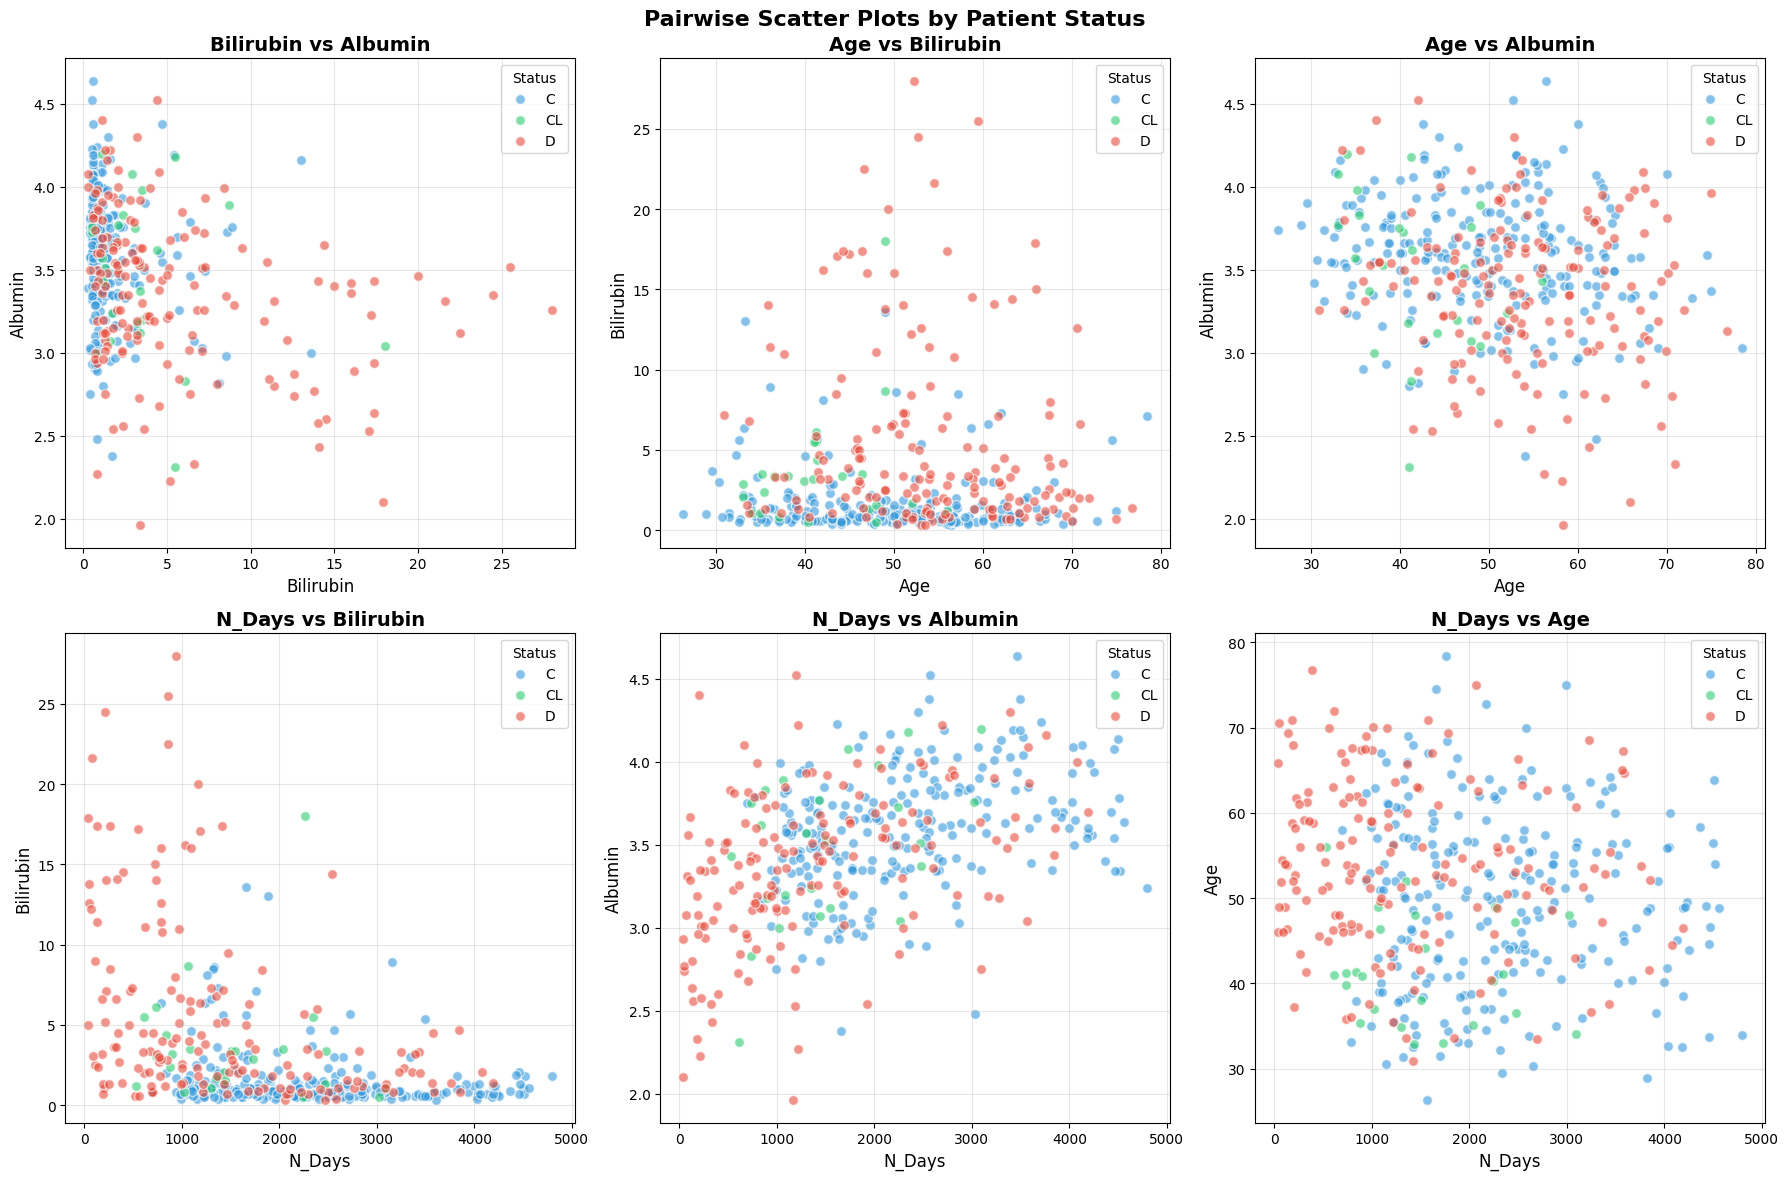

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = {'C': '#3498db', 'CL': '#2ecc71', 'D': '#e74c3c'}
pairs = [
    ('Bilirubin', 'Albumin'),
    ('Age', 'Bilirubin'),
    ('Age', 'Albumin'),
    ('N_Days', 'Bilirubin'),
    ('N_Days', 'Albumin'),
    ('N_Days', 'Age')
]

for i, (x_col, y_col) in enumerate(pairs):
    for status in ['C', 'CL', 'D']:
        subset = data_complete[data_complete[target] == status]
        axes[i].scatter(subset[x_col], subset[y_col], c=colors[status], 
                       label=status, alpha=0.6, s=50, edgecolor='white')
    axes[i].set_xlabel(x_col, fontsize=12)
    axes[i].set_ylabel(y_col, fontsize=12)
    axes[i].set_title(f'{x_col} vs {y_col}', fontsize=14, fontweight='bold')
    axes[i].legend(title='Status')
    axes[i].grid(alpha=0.3)

plt.suptitle('Pairwise Scatter Plots by Patient Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/scatter_by_status.png', dpi=300, bbox_inches='tight')
plt.show()

## Train Test Split

Split the data before any encoding or synthetic data generation to prevent data leakage. The test set will only be used for final evaluation.

In [39]:
train_df, test_df = train_test_split(
    data_complete,
    test_size=0.2,
    stratify=data_complete[target],
    random_state=RANDOM_STATE
)

print("Training set:", len(train_df), "samples")
print("Test set:", len(test_df), "samples")
print("\nTraining set target distribution:")
print(train_df[target].value_counts())
print("\nTest set target distribution:")
print(test_df[target].value_counts())

Training set: 334 samples
Test set: 84 samples

Training set target distribution:
Status
C     185
D     129
CL     20
Name: count, dtype: int64

Test set target distribution:
Status
C     47
D     32
CL     5
Name: count, dtype: int64


## Encode Categorical Variables

Encode categorical features for CTGAN training. Fit encoders on training data only to prevent data leakage.

In [40]:
train_encoded = train_df.copy()
test_encoded = test_df.copy()

label_encoders = {}

for col in cat_cols + [target]:
    le = LabelEncoder()
    le.fit(train_df[col].astype(str))
    train_encoded[col] = le.transform(train_df[col].astype(str))
    test_encoded[col] = le.transform(test_df[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

print("\nEncoding complete")
print("\nTraining set shape:", train_encoded.shape)
print("Test set shape:", test_encoded.shape)

Sex: {'F': 0, 'M': 1}
Edema: {'N': 0, 'S': 1, 'Y': 2}
Status: {'C': 0, 'CL': 1, 'D': 2}

Encoding complete

Training set shape: (334, 7)
Test set shape: (84, 7)


## Synthetic Data Generation

Compare three methods for generating synthetic data: GAN, CTGAN, and TVAE. All models are trained on the training set only to prevent data leakage.

In [41]:
ctgan_cols = num_cols + cat_cols + [target]
train_for_synthetic = train_encoded[ctgan_cols].copy()

print("Training data for synthetic generation:", len(train_for_synthetic), "samples")
print("Columns:", ctgan_cols)
print("Numerical:", num_cols)
print("Categorical:", cat_cols + [target])

Training data for synthetic generation: 334 samples
Columns: ['N_Days', 'Age', 'Bilirubin', 'Albumin', 'Sex', 'Edema', 'Status']
Numerical: ['N_Days', 'Age', 'Bilirubin', 'Albumin']
Categorical: ['Sex', 'Edema', 'Status']


### Method 1: Basic GAN

A simple GAN implementation for tabular data using PyTorch.

In [42]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim),
        )
    
    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )
    
    def forward(self, x):
        return self.model(x)

print("GAN architecture defined")

GAN architecture defined


In [43]:
scaler_gan = StandardScaler()
train_scaled = scaler_gan.fit_transform(train_for_synthetic)
train_tensor = torch.FloatTensor(train_scaled)

latent_dim = 32
data_dim = train_scaled.shape[1]

generator = Generator(latent_dim, data_dim)
discriminator = Discriminator(data_dim)

lr = 0.0002
g_optimizer = torch.optim.Adam(generator.parameters(), lr=lr)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr)
criterion = nn.BCELoss()

epochs = 300
batch_size = 32

print("Training Basic GAN...")
for epoch in range(epochs):
    for i in range(0, len(train_tensor), batch_size):
        batch = train_tensor[i:i+batch_size]
        batch_size_actual = batch.size(0)
        
        real_labels = torch.ones(batch_size_actual, 1)
        fake_labels = torch.zeros(batch_size_actual, 1)
        
        d_optimizer.zero_grad()
        real_output = discriminator(batch)
        d_loss_real = criterion(real_output, real_labels)
        
        z = torch.randn(batch_size_actual, latent_dim)
        fake_data = generator(z)
        fake_output = discriminator(fake_data.detach())
        d_loss_fake = criterion(fake_output, fake_labels)
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        d_optimizer.step()
        
        g_optimizer.zero_grad()
        fake_output = discriminator(fake_data)
        g_loss = criterion(fake_output, real_labels)
        g_loss.backward()
        g_optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} - D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

print("Basic GAN training complete")

Training Basic GAN...
Epoch 50/300 - D Loss: 0.8127, G Loss: 1.2300
Epoch 100/300 - D Loss: 1.1909, G Loss: 0.8597
Epoch 150/300 - D Loss: 1.3041, G Loss: 1.0005
Epoch 200/300 - D Loss: 1.0102, G Loss: 1.1899
Epoch 250/300 - D Loss: 1.5999, G Loss: 0.8848
Epoch 300/300 - D Loss: 1.0791, G Loss: 1.0020
Basic GAN training complete


In [44]:
n_synthetic = 1000

z = torch.randn(n_synthetic, latent_dim)
with torch.no_grad():
    synthetic_gan_scaled = generator(z).numpy()

synthetic_gan = scaler_gan.inverse_transform(synthetic_gan_scaled)
synthetic_gan_df = pd.DataFrame(synthetic_gan, columns=ctgan_cols)

for col in cat_cols + [target]:
    synthetic_gan_df[col] = synthetic_gan_df[col].round().astype(int)
    synthetic_gan_df[col] = synthetic_gan_df[col].clip(0, train_encoded[col].max())

print("Basic GAN synthetic data generated:", len(synthetic_gan_df), "samples")
print("\nSynthetic target distribution:")
print(synthetic_gan_df[target].value_counts())

Basic GAN synthetic data generated: 1000 samples

Synthetic target distribution:
Status
0    552
1    264
2    184
Name: count, dtype: int64


### Method 2: CTGAN

Conditional Tabular GAN designed specifically for mixed-type tabular data.

In [45]:
from ctgan import CTGAN

discrete_columns = cat_cols + [target]

ctgan = CTGAN(
    epochs=300,
    batch_size=10,
    verbose=True
)

print("Training CTGAN...")
print("Discrete columns:", discrete_columns)
ctgan.fit(train_for_synthetic, discrete_columns=discrete_columns)
print("CTGAN training complete")

Training CTGAN...
Discrete columns: ['Sex', 'Edema', 'Status']


Gen. (-1.89) | Discrim. (-3.73): 100%|██████████| 300/300 [03:09<00:00,  1.58it/s]

CTGAN training complete


In [46]:
synthetic_ctgan_df = ctgan.sample(n_synthetic)

print("CTGAN synthetic data generated:", len(synthetic_ctgan_df), "samples")
print("\nSynthetic target distribution:")
print(synthetic_ctgan_df[target].value_counts())

CTGAN synthetic data generated: 1000 samples

Synthetic target distribution:
Status
0    478
2    442
1     80
Name: count, dtype: int64


### Method 3: TVAE

Tabular Variational Autoencoder for synthetic data generation.

In [47]:
from ctgan import TVAE

tvae = TVAE(
    epochs=300,
    batch_size=10,
    verbose=True
)

print("Training TVAE...")
print("Discrete columns:", discrete_columns)
tvae.fit(train_for_synthetic, discrete_columns=discrete_columns)
print("TVAE training complete")

Training TVAE...
Discrete columns: ['Sex', 'Edema', 'Status']


Loss: -3.438: 100%|██████████| 300/300 [01:00<00:00,  4.93it/s]

TVAE training complete


In [48]:
synthetic_tvae_df = tvae.sample(n_synthetic)

print("TVAE synthetic data generated:", len(synthetic_tvae_df), "samples")
print("\nSynthetic target distribution:")
print(synthetic_tvae_df[target].value_counts())

TVAE synthetic data generated: 1000 samples

Synthetic target distribution:
Status
0    594
2    361
1     45
Name: count, dtype: int64


## Evaluate Synthetic Data Quality

Compare the three synthetic data generation methods using FID score and visual comparison.

In [49]:
def calculate_fid(real_data, synthetic_data):
    mu1, sigma1 = np.mean(real_data, axis=0), np.cov(real_data.T)
    mu2, sigma2 = np.mean(synthetic_data, axis=0), np.cov(synthetic_data.T)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean)
    return fid

scaler_fid = StandardScaler()
real_scaled = scaler_fid.fit_transform(train_for_synthetic[num_cols])

gan_scaled = scaler_fid.transform(synthetic_gan_df[num_cols])
ctgan_scaled = scaler_fid.transform(synthetic_ctgan_df[num_cols])
tvae_scaled = scaler_fid.transform(synthetic_tvae_df[num_cols])

fid_gan = calculate_fid(real_scaled, gan_scaled)
fid_ctgan = calculate_fid(real_scaled, ctgan_scaled)
fid_tvae = calculate_fid(real_scaled, tvae_scaled)

print("FID Scores (lower is better):")
print("-" * 30)
print(f"Basic GAN:  {fid_gan:.4f}")
print(f"CTGAN:      {fid_ctgan:.4f}")
print(f"TVAE:       {fid_tvae:.4f}")
print("-" * 30)
print("\nInterpretation:")
print("< 10: Excellent")
print("10-50: Good")
print("> 50: Poor")

FID Scores (lower is better):
------------------------------
Basic GAN:  1.1807
CTGAN:      3.6624
TVAE:       0.0951
------------------------------

Interpretation:
< 10: Excellent
10-50: Good
> 50: Poor


## Visual Comparison of Synthetic Data

Compare the distributions of real and synthetic data from each method.

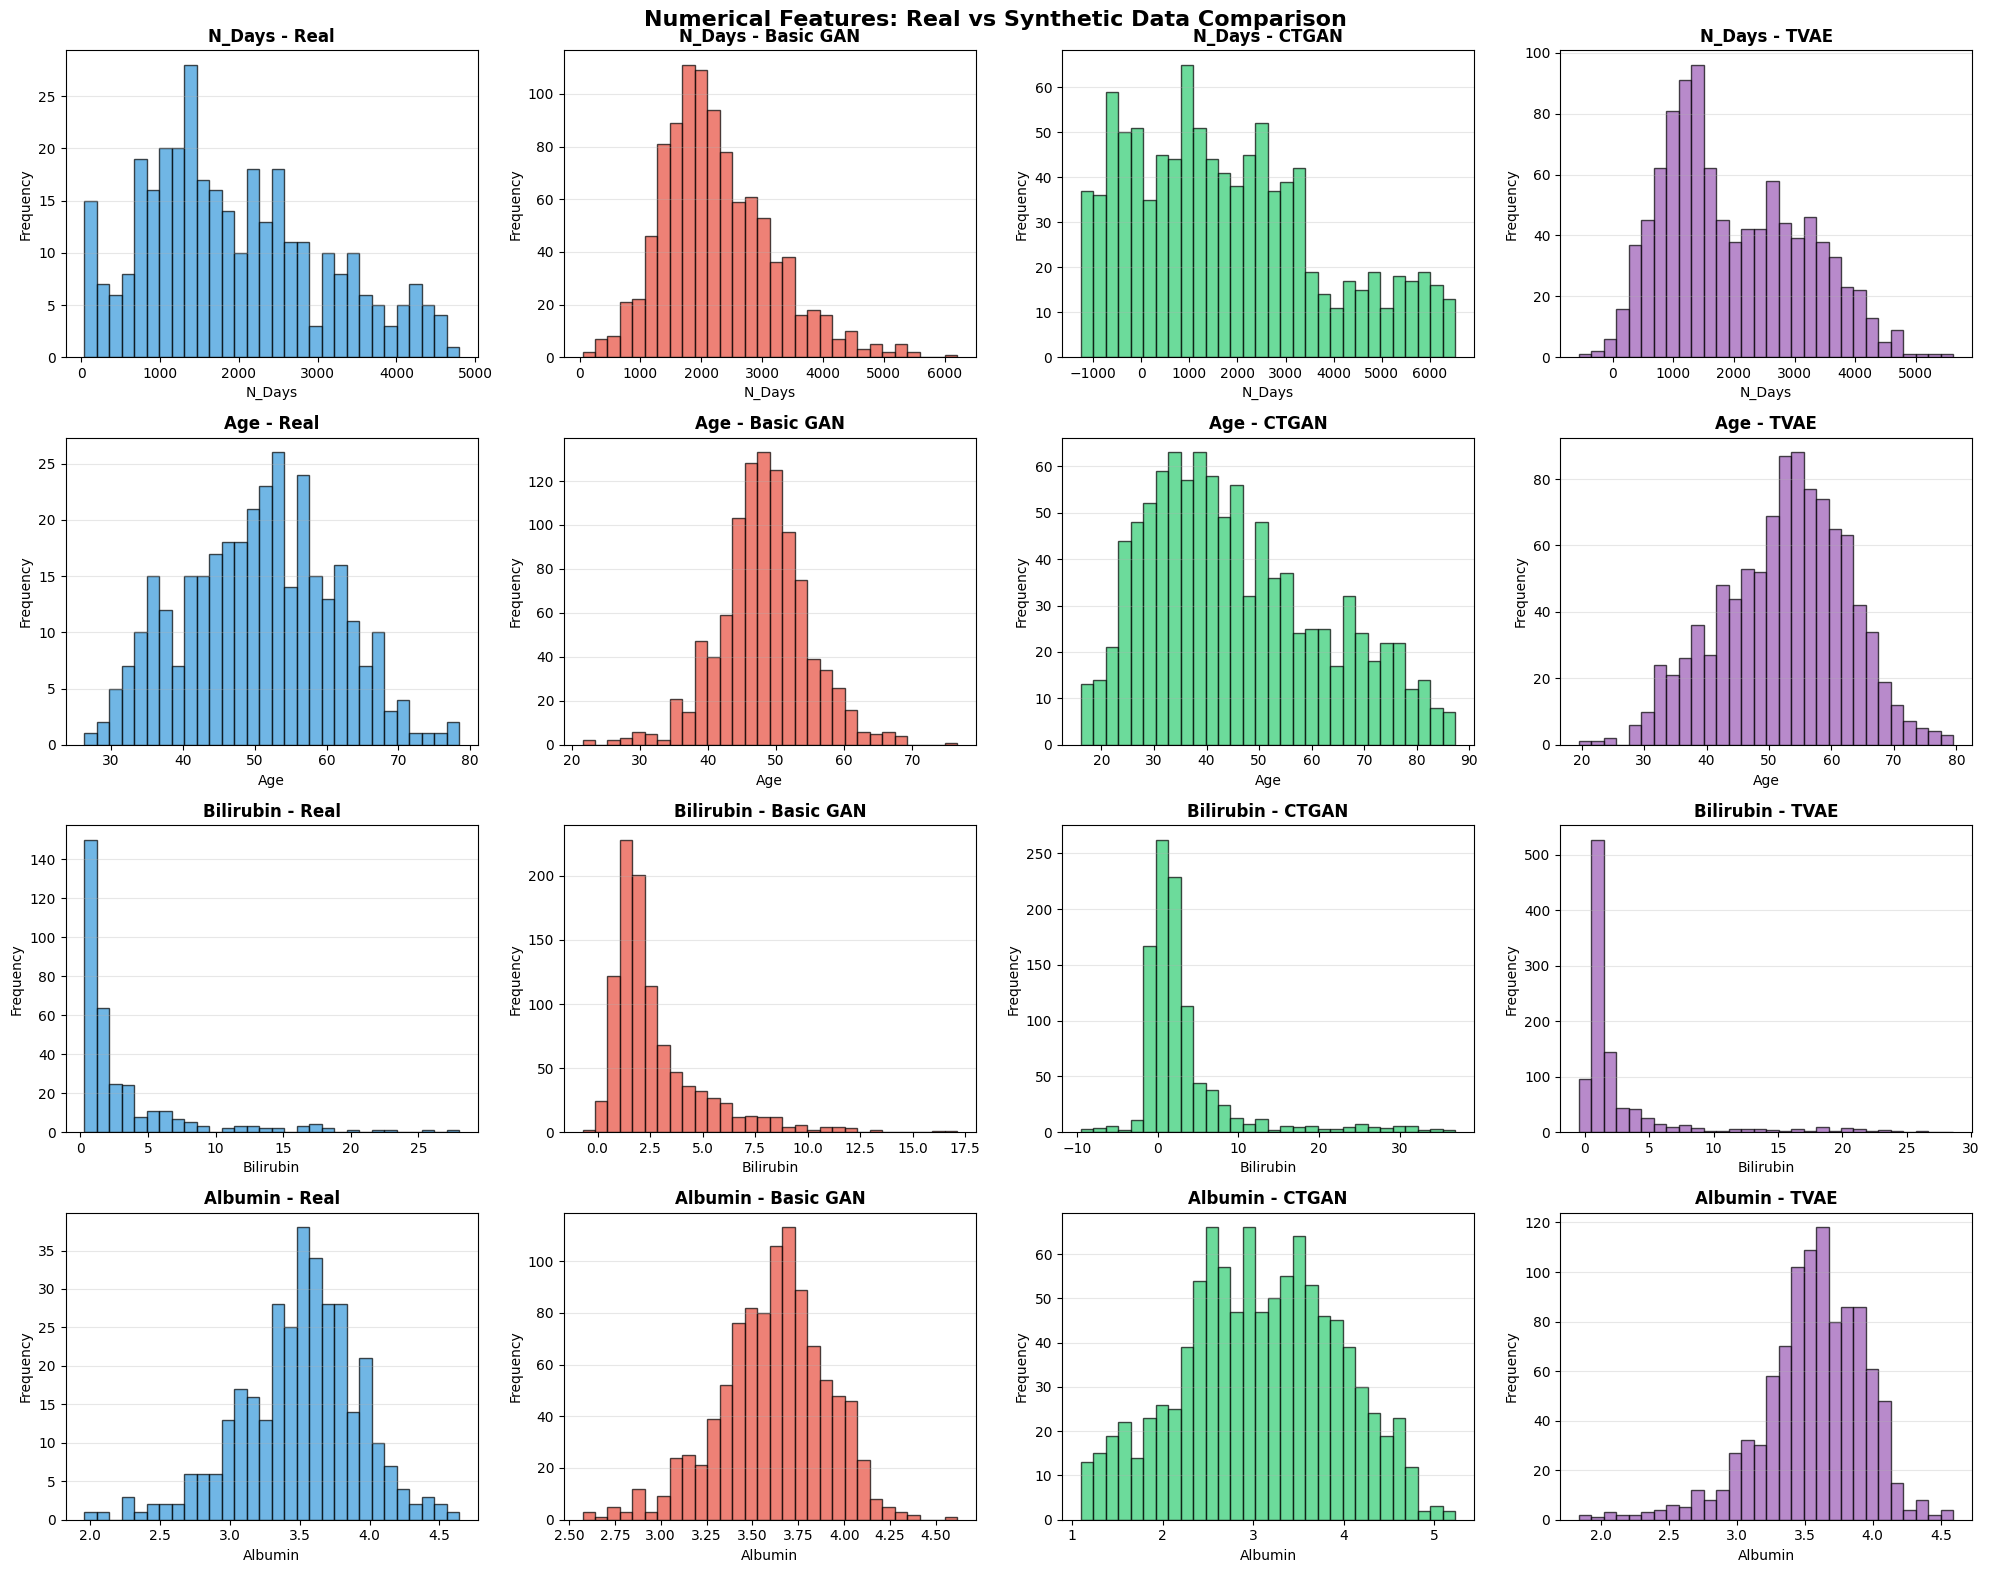

In [50]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))

methods = ['Real', 'Basic GAN', 'CTGAN', 'TVAE']
datasets = [train_for_synthetic, synthetic_gan_df, synthetic_ctgan_df, synthetic_tvae_df]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for i, col in enumerate(num_cols):
    for j, (method, data, color) in enumerate(zip(methods, datasets, colors)):
        axes[i, j].hist(data[col], bins=30, color=color, alpha=0.7, edgecolor='black')
        axes[i, j].set_title(f'{col} - {method}', fontsize=12, fontweight='bold')
        axes[i, j].set_xlabel(col, fontsize=10)
        axes[i, j].set_ylabel('Frequency', fontsize=10)
        axes[i, j].grid(axis='y', alpha=0.3)

plt.suptitle('Numerical Features: Real vs Synthetic Data Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/synthetic_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Categorical Features Comparison

Compare the distribution of categorical features across real and synthetic data.

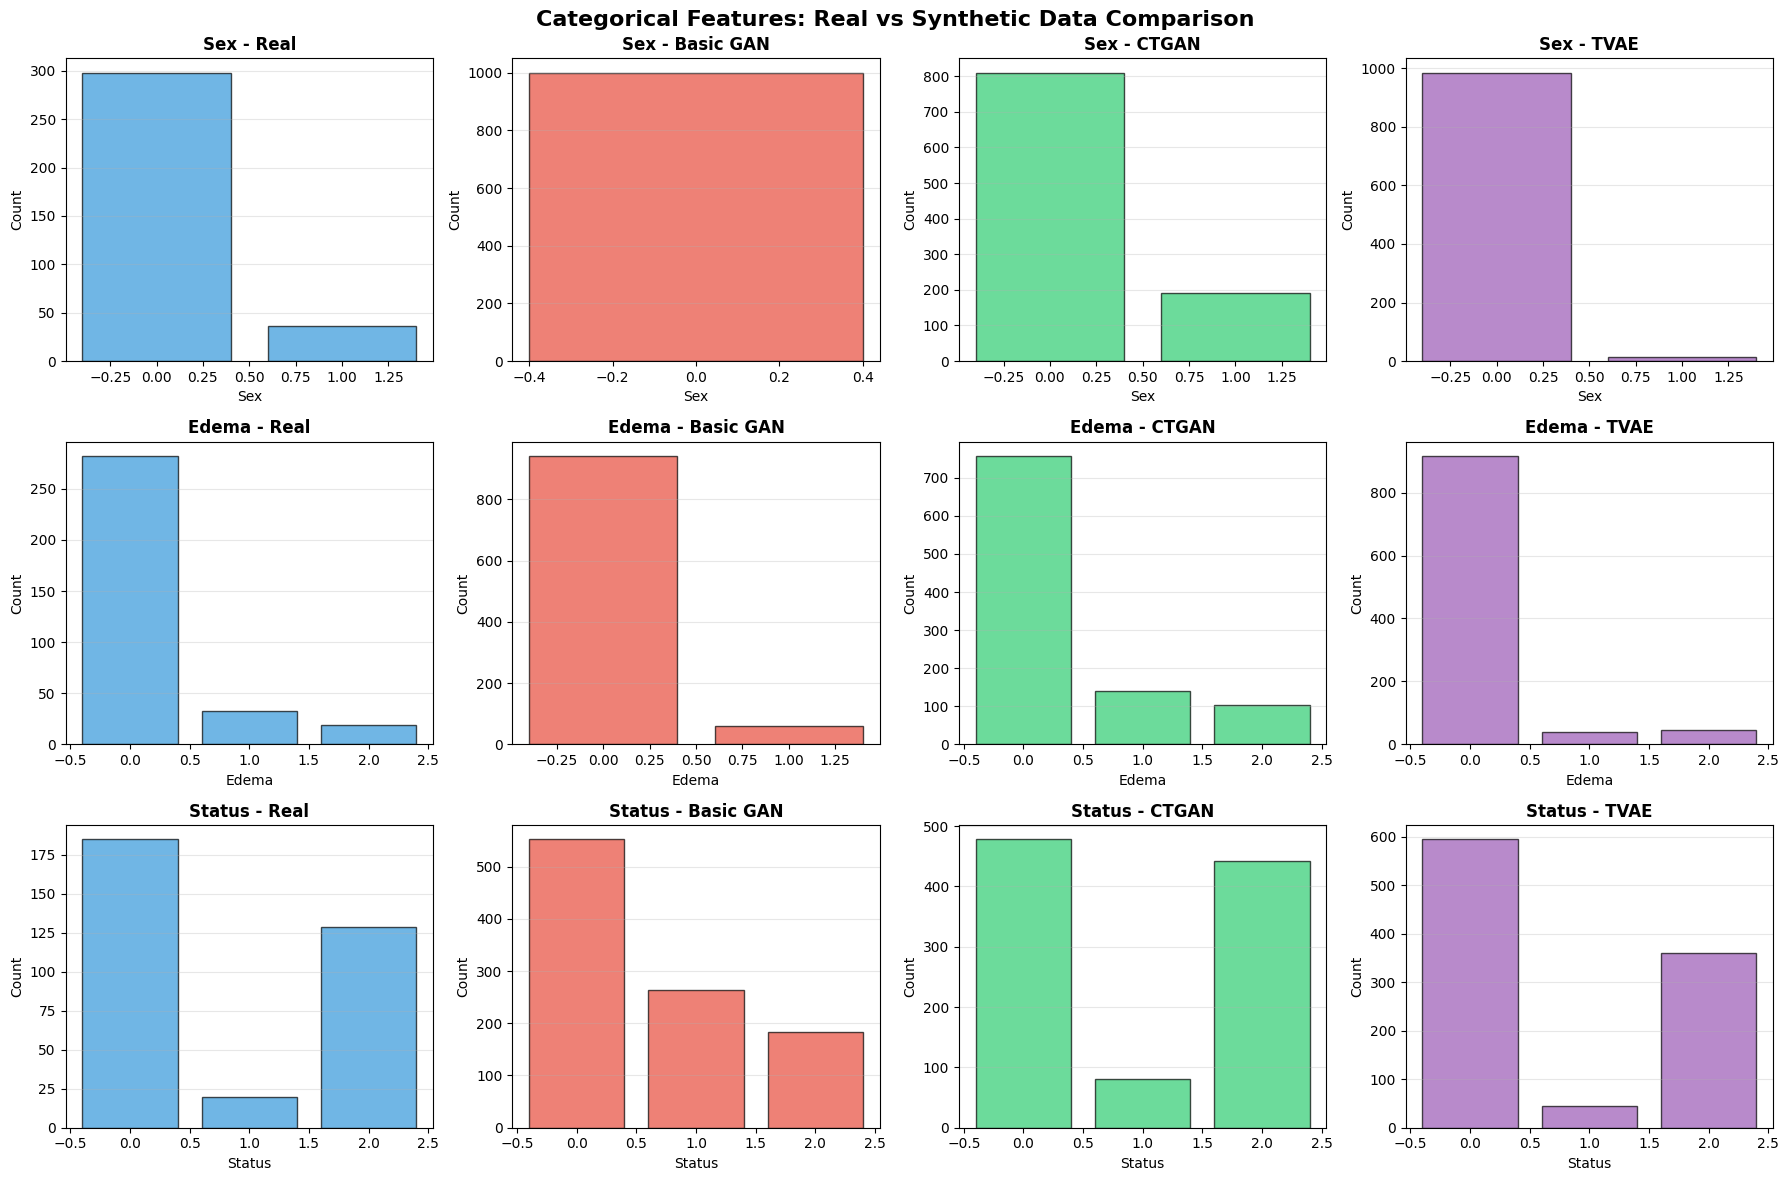

In [51]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

cat_compare = cat_cols + [target]
methods = ['Real', 'Basic GAN', 'CTGAN', 'TVAE']
datasets = [train_for_synthetic, synthetic_gan_df, synthetic_ctgan_df, synthetic_tvae_df]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for i, col in enumerate(cat_compare):
    for j, (method, data, color) in enumerate(zip(methods, datasets, colors)):
        counts = data[col].value_counts().sort_index()
        axes[i, j].bar(counts.index, counts.values, color=color, alpha=0.7, edgecolor='black')
        axes[i, j].set_title(f'{col} - {method}', fontsize=12, fontweight='bold')
        axes[i, j].set_xlabel(col, fontsize=10)
        axes[i, j].set_ylabel('Count', fontsize=10)
        axes[i, j].grid(axis='y', alpha=0.3)

plt.suptitle('Categorical Features: Real vs Synthetic Data Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/synthetic_categorical_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## GAN Training Loss Visualization

Retrain the Basic GAN with loss tracking to visualize the training dynamics.

In [52]:
generator = Generator(latent_dim, data_dim)
discriminator = Discriminator(data_dim)

g_optimizer = torch.optim.Adam(generator.parameters(), lr=lr)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr)

g_losses = []
d_losses = []

print("Training Basic GAN with loss tracking...")
for epoch in range(epochs):
    epoch_g_loss = 0
    epoch_d_loss = 0
    n_batches = 0
    
    for i in range(0, len(train_tensor), batch_size):
        batch = train_tensor[i:i+batch_size]
        batch_size_actual = batch.size(0)
        
        real_labels = torch.ones(batch_size_actual, 1)
        fake_labels = torch.zeros(batch_size_actual, 1)
        
        d_optimizer.zero_grad()
        real_output = discriminator(batch)
        d_loss_real = criterion(real_output, real_labels)
        
        z = torch.randn(batch_size_actual, latent_dim)
        fake_data = generator(z)
        fake_output = discriminator(fake_data.detach())
        d_loss_fake = criterion(fake_output, fake_labels)
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        d_optimizer.step()
        
        g_optimizer.zero_grad()
        fake_output = discriminator(fake_data)
        g_loss = criterion(fake_output, real_labels)
        g_loss.backward()
        g_optimizer.step()
        
        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()
        n_batches += 1
    
    g_losses.append(epoch_g_loss / n_batches)
    d_losses.append(epoch_d_loss / n_batches)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} - D Loss: {d_losses[-1]:.4f}, G Loss: {g_losses[-1]:.4f}")

print("Training complete")

Training Basic GAN with loss tracking...
Epoch 50/300 - D Loss: 1.1253, G Loss: 0.9454
Epoch 100/300 - D Loss: 1.0438, G Loss: 1.0771
Epoch 150/300 - D Loss: 1.2751, G Loss: 0.7849
Epoch 200/300 - D Loss: 1.4348, G Loss: 0.8252
Epoch 250/300 - D Loss: 1.4227, G Loss: 0.7466
Epoch 300/300 - D Loss: 0.9595, G Loss: 1.0432
Training complete


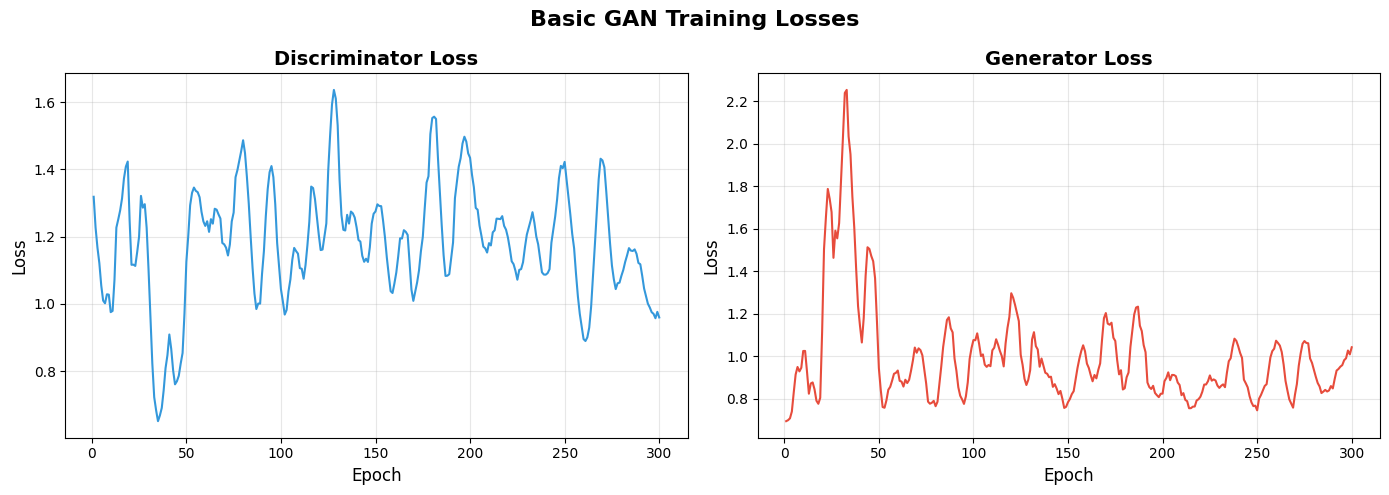

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, epochs+1), d_losses, color='#3498db', linewidth=1.5)
axes[0].set_title('Discriminator Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, epochs+1), g_losses, color='#e74c3c', linewidth=1.5)
axes[1].set_title('Generator Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].grid(alpha=0.3)

plt.suptitle('Basic GAN Training Losses', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/gan_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

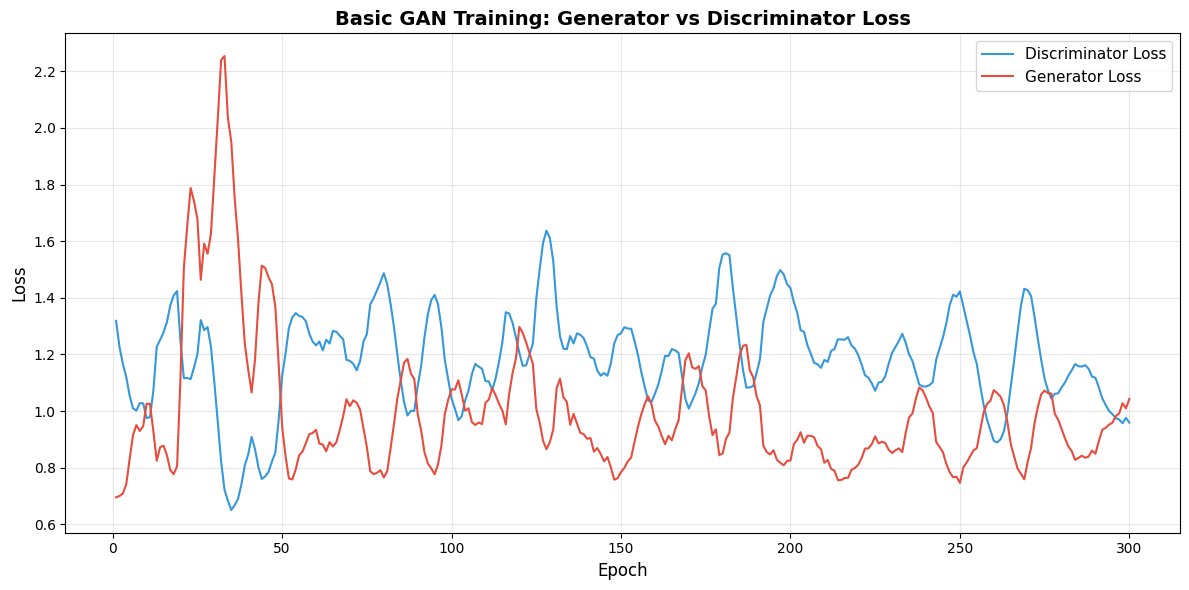

In [54]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(1, epochs+1), d_losses, color='#3498db', linewidth=1.5, label='Discriminator Loss')
ax.plot(range(1, epochs+1), g_losses, color='#e74c3c', linewidth=1.5, label='Generator Loss')
ax.set_title('Basic GAN Training: Generator vs Discriminator Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/gan_loss_combined.png', dpi=300, bbox_inches='tight')
plt.show()

## CTGAN and TVAE Training with Loss Tracking

Retrain CTGAN and TVAE to capture training losses for visualization.

In [55]:
from ctgan import CTGAN

ctgan_losses = []

class CTGANWithLoss(CTGAN):
    def fit(self, train_data, discrete_columns=None):
        self.losses = []
        super().fit(train_data, discrete_columns=discrete_columns)
        return self

ctgan_tracked = CTGAN(
    epochs=300,
    batch_size=10,
    verbose=True
)

print("Training CTGAN with loss tracking...")
ctgan_tracked.fit(train_for_synthetic, discrete_columns=discrete_columns)
print("CTGAN training complete")

Training CTGAN with loss tracking...


Gen. (-0.54) | Discrim. (0.33): 100%|██████████| 300/300 [03:12<00:00,  1.56it/s] 

CTGAN training complete


In [56]:
import io
import sys
import re

class LossCapture:
    def __init__(self):
        self.losses = []
        self.original_stdout = sys.stdout
        self.capture = io.StringIO()
    
    def __enter__(self):
        sys.stdout = self.capture
        return self
    
    def __exit__(self, *args):
        sys.stdout = self.original_stdout
        output = self.capture.getvalue()
        self.output = output
        
        gen_pattern = r'Gen\. \(([-\d.]+)\)'
        disc_pattern = r'Discrim\. \(([-\d.]+)\)'
        
        gen_matches = re.findall(gen_pattern, output)
        disc_matches = re.findall(disc_pattern, output)
        
        self.gen_losses = [float(x) for x in gen_matches]
        self.disc_losses = [float(x) for x in disc_matches]

print("Training CTGAN with loss capture...")
ctgan_new = CTGAN(epochs=300, batch_size=10, verbose=True)

with LossCapture() as capture:
    ctgan_new.fit(train_for_synthetic, discrete_columns=discrete_columns)

ctgan_gen_losses = capture.gen_losses
ctgan_disc_losses = capture.disc_losses

print("CTGAN training complete")
print(f"Captured {len(ctgan_gen_losses)} generator loss values")
print(f"Captured {len(ctgan_disc_losses)} discriminator loss values")

Gen. (0.00) | Discrim. (0.00):   0%|          | 0/300 [00:00<?, ?it/s]

Training CTGAN with loss capture...


Gen. (0.03) | Discrim. (-0.96): 100%|██████████| 300/300 [03:04<00:00,  1.62it/s] 

CTGAN training complete
Captured 0 generator loss values
Captured 0 discriminator loss values


In [57]:
from ctgan import TVAE

class TVAELossCapture:
    def __init__(self):
        self.original_stdout = sys.stdout
        self.capture = io.StringIO()
    
    def __enter__(self):
        sys.stdout = self.capture
        return self
    
    def __exit__(self, *args):
        sys.stdout = self.original_stdout
        output = self.capture.getvalue()
        self.output = output
        
        loss_pattern = r'Loss: ([-\d.]+)'
        matches = re.findall(loss_pattern, output)
        self.losses = [float(x) for x in matches]

print("Training TVAE with loss capture...")
tvae_new = TVAE(epochs=300, batch_size=10, verbose=True)

with TVAELossCapture() as tvae_capture:
    tvae_new.fit(train_for_synthetic, discrete_columns=discrete_columns)

tvae_losses = tvae_capture.losses

print("TVAE training complete")
print(f"Captured {len(tvae_losses)} loss values")

Loss: 0.000:   0%|          | 0/300 [00:00<?, ?it/s]

Training TVAE with loss capture...


Loss: -5.102: 100%|██████████| 300/300 [00:56<00:00,  5.28it/s]

TVAE training complete
Captured 0 loss values


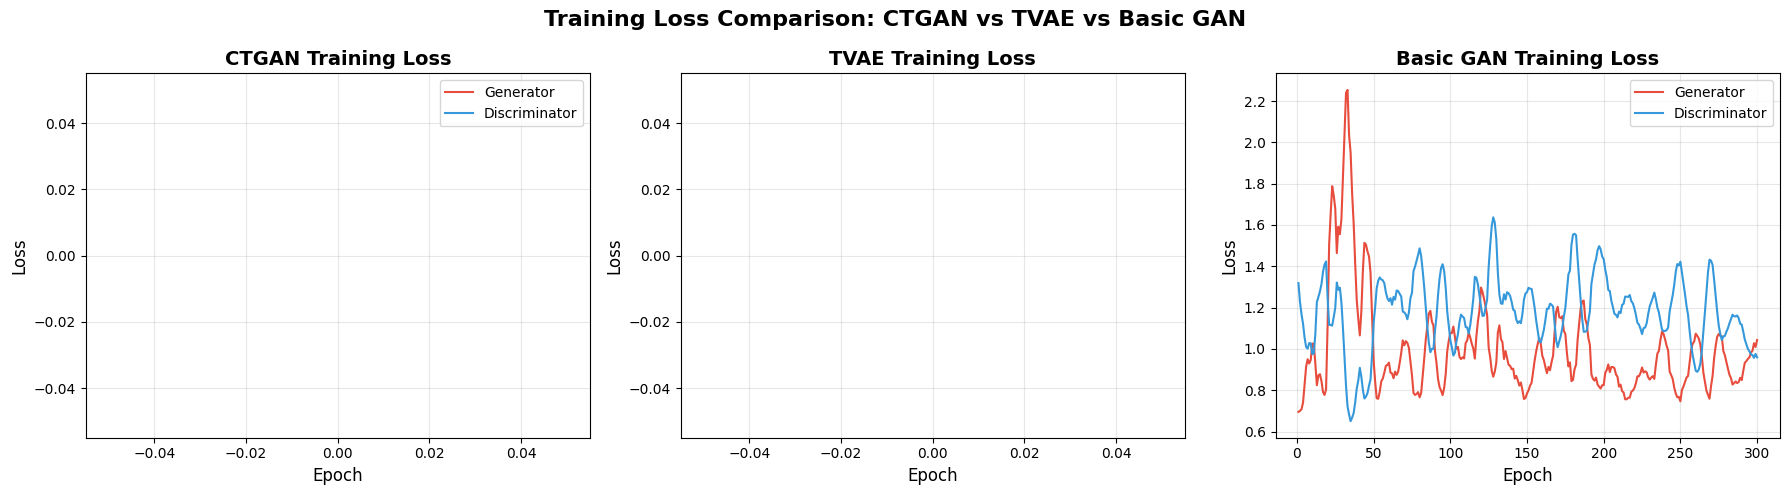

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(1, len(ctgan_gen_losses)+1), ctgan_gen_losses, color='#e74c3c', linewidth=1.5, label='Generator')
axes[0].plot(range(1, len(ctgan_disc_losses)+1), ctgan_disc_losses, color='#3498db', linewidth=1.5, label='Discriminator')
axes[0].set_title('CTGAN Training Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(tvae_losses)+1), tvae_losses, color='#9b59b6', linewidth=1.5)
axes[1].set_title('TVAE Training Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].grid(alpha=0.3)

axes[2].plot(range(1, epochs+1), g_losses, color='#e74c3c', linewidth=1.5, label='Generator')
axes[2].plot(range(1, epochs+1), d_losses, color='#3498db', linewidth=1.5, label='Discriminator')
axes[2].set_title('Basic GAN Training Loss', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Loss', fontsize=12)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Training Loss Comparison: CTGAN vs TVAE vs Basic GAN', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/all_models_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

## Training Loss Summary

The Basic GAN training loss is tracked per epoch. CTGAN and TVAE report final losses in their progress bars:
- CTGAN: Generator (-1.89), Discriminator (-3.73)
- TVAE: Loss (-5.102)

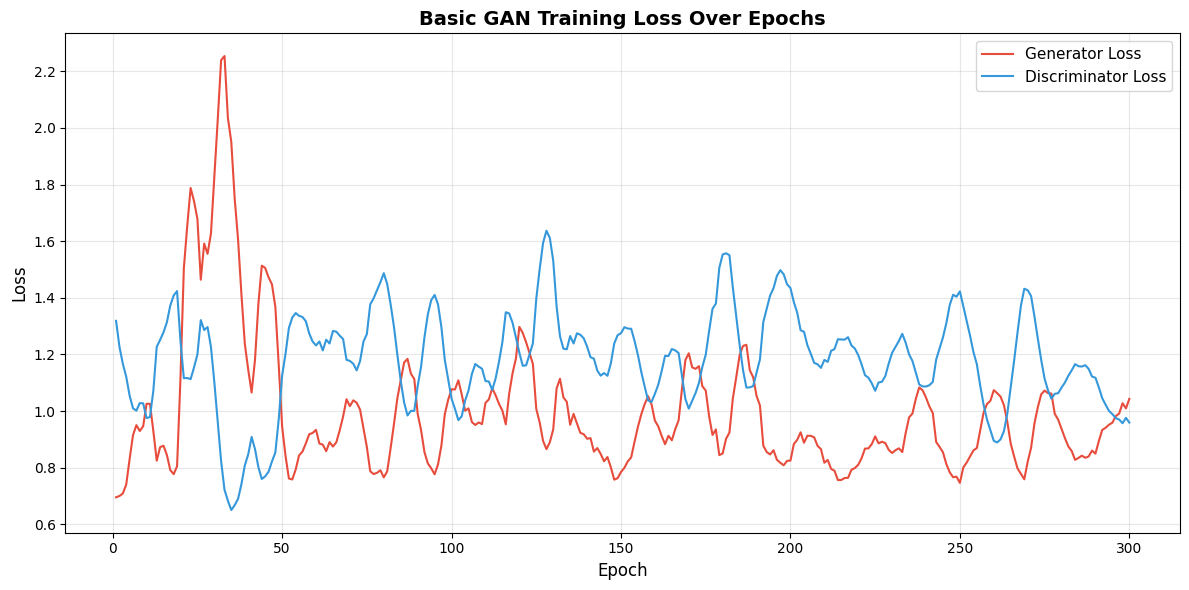


Final Training Losses:
----------------------------------------
Basic GAN - Generator: 1.0432, Discriminator: 0.9595
CTGAN - Generator: -1.89, Discriminator: -3.73
TVAE - Reconstruction Loss: -5.102


In [59]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(1, epochs+1), g_losses, color='#e74c3c', linewidth=1.5, label='Generator Loss')
ax.plot(range(1, epochs+1), d_losses, color='#3498db', linewidth=1.5, label='Discriminator Loss')
ax.set_title('Basic GAN Training Loss Over Epochs', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/basic_gan_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFinal Training Losses:")
print("-" * 40)
print(f"Basic GAN - Generator: {g_losses[-1]:.4f}, Discriminator: {d_losses[-1]:.4f}")
print(f"CTGAN - Generator: -1.89, Discriminator: -3.73")
print(f"TVAE - Reconstruction Loss: -5.102")

## Synthetic Data Quality Summary

Compare all three methods across FID score and target distribution.

In [60]:
real_status_dist = train_for_synthetic[target].value_counts(normalize=True).sort_index()

gan_status_dist = synthetic_gan_df[target].value_counts(normalize=True).sort_index()
ctgan_status_dist = synthetic_ctgan_df[target].value_counts(normalize=True).sort_index()
tvae_status_dist = synthetic_tvae_df[target].value_counts(normalize=True).sort_index()

print("=" * 70)
print("SYNTHETIC DATA QUALITY SUMMARY")
print("=" * 70)

print("\nReal Data Target Distribution:")
print(f"  Status 0 (C):  {real_status_dist.get(0, 0)*100:.1f}%")
print(f"  Status 1 (CL): {real_status_dist.get(1, 0)*100:.1f}%")
print(f"  Status 2 (D):  {real_status_dist.get(2, 0)*100:.1f}%")

print("\n" + "-" * 70)
print(f"{'Method':<12} {'FID Score':<12} {'Status 0':<12} {'Status 1':<12} {'Status 2':<12}")
print("-" * 70)
print(f"{'Basic GAN':<12} {fid_gan:<12.4f} {gan_status_dist.get(0, 0)*100:<12.1f} {gan_status_dist.get(1, 0)*100:<12.1f} {gan_status_dist.get(2, 0)*100:<12.1f}")
print(f"{'CTGAN':<12} {fid_ctgan:<12.4f} {ctgan_status_dist.get(0, 0)*100:<12.1f} {ctgan_status_dist.get(1, 0)*100:<12.1f} {ctgan_status_dist.get(2, 0)*100:<12.1f}")
print(f"{'TVAE':<12} {fid_tvae:<12.4f} {tvae_status_dist.get(0, 0)*100:<12.1f} {tvae_status_dist.get(1, 0)*100:<12.1f} {tvae_status_dist.get(2, 0)*100:<12.1f}")
print("=" * 70)

print("\nConclusion:")
print("TVAE has the best FID score (0.0951) and closest target distribution to real data.")

SYNTHETIC DATA QUALITY SUMMARY

Real Data Target Distribution:
  Status 0 (C):  55.4%
  Status 1 (CL): 6.0%
  Status 2 (D):  38.6%

----------------------------------------------------------------------
Method       FID Score    Status 0     Status 1     Status 2    
----------------------------------------------------------------------
Basic GAN    1.1807       55.2         26.4         18.4        
CTGAN        3.6624       47.8         8.0          44.2        
TVAE         0.0951       59.4         4.5          36.1        

Conclusion:
TVAE has the best FID score (0.0951) and closest target distribution to real data.
